In [47]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# Set up scanpy settings
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white')




In [48]:
# Load single cell data
print("🔄 Loading single cell data...")
adata_sc_path = "/Users/yashkulkarni/cellxgene_data/processed_deconvolution_sc_spleen_240713_fixed_full_data.h5ad"
adata_sc = sc.read_h5ad(adata_sc_path)

print(f"   ✓ Original data shape: {adata_sc.shape}")
print(f"   ✓ Timepoints: {adata_sc.obs['timepoint'].unique()}")
print(f"   ✓ Cell type columns: 'celltypes_redo' ({adata_sc.obs['celltypes_redo'].nunique()} types), 'coarse_redo' ({adata_sc.obs['coarse_redo'].nunique()} types)")

# Check timepoint distribution
timepoint_counts = adata_sc.obs['timepoint'].value_counts()
print(f"\nTimepoint distribution:")
for tp, count in timepoint_counts.items():
    print(f"   • {tp:<20} | {count:>6,} cells")


🔄 Loading single cell data...
   ✓ Original data shape: (60686, 32984)
   ✓ Timepoints: ['3wk', '0wk']
Categories (2, object): ['0wk', '3wk']
   ✓ Cell type columns: 'celltypes_redo' (45 types), 'coarse_redo' (10 types)

Timepoint distribution:
   • 0wk                  | 31,994 cells
   • 3wk                  | 28,692 cells


In [49]:
# Load interferon gamma response gene set - MOUSE VERSION
print("🧬 LOADING MOUSE INTERFERON GAMMA RESPONSE GENE SET")
print("=================================================")

# Load the mouse hallmark collection that we found working
try:
    print("📁 Loading from MSigDB_Hallmark_2020...")
    mouse_hallmark = gp.get_library(name='MSigDB_Hallmark_2020', organism='Mouse')
    print(f"✓ Loaded mouse hallmark collection with {len(mouse_hallmark)} gene sets")
    
    # Look for interferon-related gene sets
    interferon_sets = {}
    for gene_set_name, genes in mouse_hallmark.items():
        if 'interferon' in gene_set_name.lower():
            interferon_sets[gene_set_name] = genes
            print(f"      ⭐ FOUND INTERFERON SET: {gene_set_name}")
    
    # Use Interferon Gamma Response
    target_set = 'Interferon Gamma Response'
    if target_set in mouse_hallmark:
        interferon_gamma_genes = {target_set: mouse_hallmark[target_set]}
        print(f"\n🎯 Using: {target_set}")
        print(f"✓ Gene set contains {len(interferon_gamma_genes[target_set])} genes")
        print(f"✓ First 10 genes: {interferon_gamma_genes[target_set][:10]}")
        print(f"\n✅ SUCCESS! Ready to proceed with GSEA analysis")
        print(f"✅ Using gene set: {target_set}")
        print(f"✅ Total genes: {len(interferon_gamma_genes[target_set])}")
    else:
        print(f"❌ Could not find '{target_set}' in mouse hallmark collection")
        
except Exception as e:
    print(f"❌ Error loading mouse gene sets: {e}")
    # Fallback to human gene set if mouse fails
    print("🔄 Falling back to human gene set...")
    human_interferon = gp.get_library(name='HALLMARK_INTERFERON_GAMMA_RESPONSE', organism='Human')
    interferon_gamma_genes = human_interferon
    print(f"✓ Using human interferon gamma response gene set as fallback")


🧬 LOADING MOUSE INTERFERON GAMMA RESPONSE GENE SET
📁 Loading from MSigDB_Hallmark_2020...
✓ Loaded mouse hallmark collection with 50 gene sets
      ⭐ FOUND INTERFERON SET: Interferon Alpha Response
      ⭐ FOUND INTERFERON SET: Interferon Gamma Response

🎯 Using: Interferon Gamma Response
✓ Gene set contains 200 genes
✓ First 10 genes: ['GBP6', 'MX1', 'SP110', 'MX2', 'RSAD2', 'PSMB9', 'PML', 'NUP93', 'LAP3', 'MTHFD2']

✅ SUCCESS! Ready to proceed with GSEA analysis
✅ Using gene set: Interferon Gamma Response
✅ Total genes: 200


In [50]:
# SOLUTION: Load mouse interferon gamma response gene set
print("🧬 LOADING MOUSE INTERFERON GAMMA RESPONSE GENE SET")
print("=================================================")

# Let's try multiple approaches to get mouse interferon gamma response genes

# Approach 1: Try to load from the available mouse hallmark collection
try:
    print("📁 Approach 1: Loading from MSigDB_Hallmark_2020...")
    mouse_hallmarks = gp.get_library(name='MSigDB_Hallmark_2020', organism='Mouse')
    
    print(f"✓ Loaded mouse hallmark collection with {len(mouse_hallmarks)} gene sets")
    print("Available gene sets:")
    for i, gene_set_name in enumerate(mouse_hallmarks.keys()):
        print(f"  {i+1:2d}. {gene_set_name}")
        if 'interferon' in gene_set_name.lower():
            print(f"      ⭐ FOUND INTERFERON SET!")
    
    # Check if interferon gamma response is in there
    interferon_sets = [name for name in mouse_hallmarks.keys() if 'interferon' in name.lower()]
    if interferon_sets:
        print(f"\n✓ Found {len(interferon_sets)} interferon-related gene sets:")
        for iset in interferon_sets:
            print(f"  - {iset}")
            
        # Use the gamma interferon set if available
        gamma_sets = [name for name in interferon_sets if 'gamma' in name.lower()]
        if gamma_sets:
            interferon_gamma_genes = {gamma_sets[0]: mouse_hallmarks[gamma_sets[0]]}
            used_gene_set = gamma_sets[0]
            print(f"\n🎯 Using: {used_gene_set}")
            print(f"✓ Gene set contains {len(interferon_gamma_genes[used_gene_set])} genes")
            print(f"✓ First 10 genes: {interferon_gamma_genes[used_gene_set][:10]}")
        else:
            # Use any interferon set as backup
            interferon_gamma_genes = {interferon_sets[0]: mouse_hallmarks[interferon_sets[0]]}
            used_gene_set = interferon_sets[0]
            print(f"\n🎯 Using interferon set: {used_gene_set}")
            print(f"✓ Gene set contains {len(interferon_gamma_genes[used_gene_set])} genes")
    else:
        print("\n⚠️  No interferon sets found in mouse hallmarks")
        interferon_gamma_genes = None
        
except Exception as e:
    print(f"✗ Approach 1 failed: {e}")
    interferon_gamma_genes = None

# Approach 2: Use human genes and convert to mouse orthologs
if interferon_gamma_genes is None:
    print("\n📁 Approach 2: Converting human interferon gamma genes to mouse...")
    try:
        # Load human interferon gamma response
        human_interferon = gp.get_library(name='HALLMARK_INTERFERON_GAMMA_RESPONSE', organism='Human')
        human_genes = human_interferon['HALLMARK_INTERFERON_GAMMA_RESPONSE']
        
        print(f"✓ Loaded human interferon gamma response: {len(human_genes)} genes")
        
        # Convert human genes to mouse orthologs
        # We'll use a simple mapping approach - many genes have same symbols
        # For a more sophisticated approach, you could use biomart or other ortholog databases
        
        # For now, let's use the human gene set as a proxy
        # In your mouse data, some genes will match directly by symbol
        interferon_gamma_genes = {'HALLMARK_INTERFERON_GAMMA_RESPONSE_MOUSE': human_genes}
        used_gene_set = 'HALLMARK_INTERFERON_GAMMA_RESPONSE_MOUSE'
        
        print(f"✓ Created mouse interferon gamma gene set (human orthologs)")
        print(f"✓ Gene set contains {len(human_genes)} genes")
        print(f"✓ First 10 genes: {human_genes[:10]}")
        print("⚠️  Note: Using human gene symbols - many will have mouse orthologs with same symbols")
        
    except Exception as e:
        print(f"✗ Approach 2 failed: {e}")
        interferon_gamma_genes = None

# Final check
if interferon_gamma_genes is not None:
    print(f"\n✅ SUCCESS! Ready to proceed with GSEA analysis")
    print(f"✅ Using gene set: {used_gene_set}")
    print(f"✅ Total genes: {len(list(interferon_gamma_genes.values())[0])}")
else:
    print(f"\n❌ Could not load interferon gamma gene set")
    print("💡 Alternative: You could manually define interferon response genes")
    print("💡 Or use GO terms related to interferon response")


🧬 LOADING MOUSE INTERFERON GAMMA RESPONSE GENE SET
📁 Approach 1: Loading from MSigDB_Hallmark_2020...
✓ Loaded mouse hallmark collection with 50 gene sets
Available gene sets:
   1. TNF-alpha Signaling via NF-kB
   2. Hypoxia
   3. Cholesterol Homeostasis
   4. Mitotic Spindle
   5. Wnt-beta Catenin Signaling
   6. TGF-beta Signaling
   7. IL-6/JAK/STAT3 Signaling
   8. DNA Repair
   9. G2-M Checkpoint
  10. Apoptosis
  11. Notch Signaling
  12. Adipogenesis
  13. Estrogen Response Early
  14. Estrogen Response Late
  15. Androgen Response
  16. Myogenesis
  17. Protein Secretion
  18. Interferon Alpha Response
      ⭐ FOUND INTERFERON SET!
  19. Interferon Gamma Response
      ⭐ FOUND INTERFERON SET!
  20. Apical Junction
  21. Apical Surface
  22. Hedgehog Signaling
  23. Complement
  24. Unfolded Protein Response
  25. PI3K/AKT/mTOR  Signaling
  26. mTORC1 Signaling
  27. E2F Targets
  28. Myc Targets V1
  29. Myc Targets V2
  30. Epithelial Mesenchymal Transition
  31. Inflammatory

In [51]:
# CORRECTED GSEA function - proper differential expression between conditions
def run_gsea_for_celltype_corrected(adata, celltype_col, celltype_name, gene_set_dict, 
                                   condition_col='timepoint', infected_condition='3wk', 
                                   uninfected_condition='0wk'):
    """
    Run GSEA for a specific cell type comparing infected vs uninfected
    Uses proper differential expression analysis between conditions
    """
    
    print(f"  🔍 Analyzing {celltype_name}...")
    
    try:
        # Filter data for this specific cell type
        cell_mask = adata.obs[celltype_col] == celltype_name
        adata_subset = adata[cell_mask].copy()
        
        # Check if we have both conditions
        conditions = adata_subset.obs[condition_col].unique()
        if len(conditions) < 2:
            print(f"    ⚠️  Only one condition found: {conditions}")
            return None
            
        # Count cells in each condition
        infected_count = sum(adata_subset.obs[condition_col] == infected_condition)
        uninfected_count = sum(adata_subset.obs[condition_col] == uninfected_condition)
        
        print(f"    📊 Cells - Infected: {infected_count}, Uninfected: {uninfected_count}")
        
        # Need minimum cells for analysis
        if infected_count < 10 or uninfected_count < 10:
            print(f"    ⚠️  Too few cells for analysis")
            return None
        
        # Perform differential expression analysis: infected vs uninfected
        sc.tl.rank_genes_groups(adata_subset, 
                               groupby=condition_col,
                               groups=[infected_condition],
                               reference=uninfected_condition,
                               method='wilcoxon',
                               key_added='rank_genes_groups')
        
        # Extract differential expression results
        de_results = sc.get.rank_genes_groups_df(adata_subset, group=infected_condition)
        
        # Create ranked gene list for GSEA
        de_clean = de_results.dropna(subset=['logfoldchanges']).copy()
        
        if len(de_clean) == 0:
            print(f"    ⚠️  No valid DE genes found")
            return None
        
        # Create the ranking metric (log fold change with small noise to break ties)
        de_clean['rank_metric'] = de_clean['logfoldchanges'] + np.random.normal(0, 1e-6, len(de_clean))
        gene_ranking = de_clean.set_index('names')['rank_metric'].sort_values(ascending=False)
        gene_ranking = gene_ranking[~gene_ranking.index.duplicated(keep='first')]
        
        print(f"    📈 Using {len(gene_ranking)} genes for GSEA")
        
        # Run GSEA using prerank
        gsea_results = gp.prerank(
            rnk=gene_ranking,  
            gene_sets=gene_set_dict,  
            permutation_num=1000,  
            outdir=None,  
            seed=42,  
            verbose=False  
        )
        
        # Extract results
        gene_set_name = list(gene_set_dict.keys())[0]  
        
        if hasattr(gsea_results, 'res2d') and len(gsea_results.res2d) > 0:
            result_row = gsea_results.res2d.iloc[0]  
            
            return {
                'celltype': celltype_name,
                'gene_set': gene_set_name,
                'nes': result_row['NES'],  
                'pval': result_row['NOM p-val'],
                'fdr': result_row['FDR q-val'],
                'es': result_row['ES'],  
                'size': result_row['geneset_size'],
                'infected_cells': infected_count,
                'uninfected_cells': uninfected_count,
                'log2fc_mean': de_clean['logfoldchanges'].mean(),
                'n_upregulated': sum(de_clean['logfoldchanges'] > 0),
                'n_downregulated': sum(de_clean['logfoldchanges'] < 0)
            }
        else:
            print(f"    ⚠️  No GSEA results returned")
            return None
            
    except Exception as e:
        print(f"    ❌ Error running GSEA: {e}")
        return None

In [52]:
# CORRECTED plotting function for single NES values per cell type
def plot_gsea_results_corrected(results_df, title, figsize=(12, 8), save_path=None):
    """
    Create bar plot showing NES for each cell type (infected vs uninfected comparison)
    """
    
    if len(results_df) == 0:
        print(f"No results to plot for {title}")
        return None
    
    # Sort by NES for better visualization
    plot_data = results_df.sort_values('nes', ascending=False).copy()
    
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Create color map based on significance and direction
    colors = []
    for _, row in plot_data.iterrows():
        if row['fdr'] < 0.05:
            if row['nes'] > 0:
                colors.append('#d62728')  # Red for significant enrichment in infected
            else:
                colors.append('#2ca02c')  # Green for significant enrichment in uninfected
        else:
            colors.append('#7f7f7f')  # Gray for non-significant
    
    # Create bars
    bars = ax.bar(range(len(plot_data)), plot_data['nes'], 
                  color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # Customize plot
    ax.set_xlabel('Cell Type', fontsize=12, fontweight='bold')
    ax.set_ylabel('Normalized Enrichment Score (NES)', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(range(len(plot_data)))
    ax.set_xticklabels(plot_data['celltype'], rotation=45, ha='right', fontsize=10)
    
    # Add horizontal line at zero
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    
    # Add significance stars
    for i, (_, row) in enumerate(plot_data.iterrows()):
        if row['fdr'] < 0.05:
            y_pos = row['nes'] + 0.1 if row['nes'] > 0 else row['nes'] - 0.15
            ax.text(i, y_pos, '*', ha='center', va='bottom' if row['nes'] > 0 else 'top',
                   fontsize=16, fontweight='bold', color='black')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#d62728', label='Enriched in Infected (FDR < 0.05)'),
        Patch(facecolor='#2ca02c', label='Enriched in Uninfected (FDR < 0.05)'),
        Patch(facecolor='#7f7f7f', label='Not Significant')
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=10)
    
    # Add grid
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    # Save if requested
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✅ Saved figure: {save_path}")
    
    plt.show()
    return fig

# Run CORRECTED GSEA analysis for COARSE cell types
print("🔥 RUNNING CORRECTED GSEA ANALYSIS - COARSE CELL TYPES")
print("==================================================")

coarse_celltypes = adata_sc.obs['coarse_redo'].unique()
print(f"✓ Found {len(coarse_celltypes)} coarse cell types")
print(f"   Cell types: {list(coarse_celltypes)}")

coarse_results_corrected = []
for celltype in coarse_celltypes:
    if pd.notna(celltype):
        result = run_gsea_for_celltype_corrected(adata_sc, 
                                               celltype_col='coarse_redo', 
                                               celltype_name=celltype,
                                               gene_set_dict=interferon_gamma_genes)
        if result is not None:
            coarse_results_corrected.append(result)

if len(coarse_results_corrected) > 0:
    coarse_df_corrected = pd.DataFrame(coarse_results_corrected)
    print(f"\n✅ COARSE ANALYSIS COMPLETE")
    print(f"✅ Successfully analyzed {len(coarse_df_corrected)} cell types")
    
    # Show summary
    significant = coarse_df_corrected[coarse_df_corrected['fdr'] < 0.05]
    print(f"✅ Significant results: {len(significant)}")
    if len(significant) > 0:
        print("📊 Significant cell types:")
        for _, row in significant.iterrows():
            direction = "↑ Infected" if row['nes'] > 0 else "↓ Uninfected"
            print(f"   {row['celltype']:<20} | NES: {row['nes']:>6.2f} | {direction}")
else:
    print(f"\n❌ No successful GSEA results for coarse cell types")
    coarse_df_corrected = pd.DataFrame()

# Run CORRECTED GSEA analysis for FINE cell types  
print("\n🔥 RUNNING CORRECTED GSEA ANALYSIS - FINE CELL TYPES")
print("==================================================")

fine_celltypes = adata_sc.obs['celltypes_redo'].unique()
print(f"✓ Found {len(fine_celltypes)} fine cell types")

fine_results_corrected = []
for celltype in fine_celltypes:
    if pd.notna(celltype):
        result = run_gsea_for_celltype_corrected(adata_sc, 
                                               celltype_col='celltypes_redo', 
                                               celltype_name=celltype,
                                               gene_set_dict=interferon_gamma_genes)
        if result is not None:
            fine_results_corrected.append(result)

if len(fine_results_corrected) > 0:
    fine_df_corrected = pd.DataFrame(fine_results_corrected)
    print(f"\n✅ FINE ANALYSIS COMPLETE")
    print(f"✅ Successfully analyzed {len(fine_df_corrected)} cell types")
    
    # Show summary
    significant = fine_df_corrected[fine_df_corrected['fdr'] < 0.05]
    print(f"✅ Significant results: {len(significant)}")
    if len(significant) > 0:
        print("📊 Significant cell types:")
        for _, row in significant.iterrows():
            direction = "↑ Infected" if row['nes'] > 0 else "↓ Uninfected"
            print(f"   {row['celltype']:<30} | NES: {row['nes']:>6.2f} | {direction}")
else:
    print(f"\n❌ No successful GSEA results for fine cell types")
    fine_df_corrected = pd.DataFrame()

# Create the CORRECTED plots
print("\n📊 CREATING CORRECTED PLOTS")
print("==================================================")

# Plot coarse cell types
if len(coarse_df_corrected) > 0:
    print("🎨 Creating coarse cell types plot...")
    coarse_fig = plot_gsea_results_corrected(
        coarse_df_corrected, 
        title="Interferon Gamma Response: Infected vs Uninfected (Coarse Cell Types)",
        figsize=(12, 8),
        save_path="interferon_gamma_gsea_coarse_CORRECTED.png"
    )

# Plot fine cell types  
if len(fine_df_corrected) > 0:
    print("🎨 Creating fine cell types plot...")
    fine_fig = plot_gsea_results_corrected(
        fine_df_corrected, 
        title="Interferon Gamma Response: Infected vs Uninfected (Fine Cell Types)",
        figsize=(16, 12),
        save_path="interferon_gamma_gsea_fine_CORRECTED.png"
    )

# Save corrected results
print("\n💾 SAVING CORRECTED RESULTS")
print("==================================================")

if len(coarse_df_corrected) > 0:
    coarse_df_corrected.to_csv('interferon_gamma_gsea_coarse_CORRECTED.csv', index=False)
    print(f"✅ Saved coarse results: interferon_gamma_gsea_coarse_CORRECTED.csv")

if len(fine_df_corrected) > 0:
    fine_df_corrected.to_csv('interferon_gamma_gsea_fine_CORRECTED.csv', index=False)
    print(f"✅ Saved fine results: interferon_gamma_gsea_fine_CORRECTED.csv")

print("\n🎉 CORRECTED ANALYSIS COMPLETE!")

🔥 RUNNING CORRECTED GSEA ANALYSIS - COARSE CELL TYPES
✓ Found 10 coarse cell types
   Cell types: ['Hematopoietic', 'Myeloid', 'CD8-Tcell', 'CD4-Tcell', 'NK', 'Neutrophil', 'Bcell', 'Mast-Cell', 'Endothelial', 'Fibroblast']
  🔍 Analyzing Hematopoietic...
    📊 Cells - Infected: 1836, Uninfected: 2254
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)
    📈 Using 32984 genes for GSEA
    ❌ Error running GSEA: 'geneset_size'
  🔍 Analyzing Myeloid...
    📊 Cells - Infected: 7943, Uninfected: 5225
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be index

In [53]:
# CORRECTED GSEA function - separate enrichment for infected vs uninfected
def run_gsea_for_celltype_separate_conditions(adata, celltype_col, celltype_name, gene_set_dict, 
                                            condition_col='timepoint', infected_condition='3wk', 
                                            uninfected_condition='0wk'):
    """
    Run GSEA separately for infected and uninfected cells of the same cell type
    Returns separate enrichment scores for each condition
    """
    
    print(f"  🔍 Analyzing {celltype_name}...")
    
    try:
        # Filter data for this specific cell type
        cell_mask = adata.obs[celltype_col] == celltype_name
        adata_subset = adata[cell_mask].copy()
        
        # Check if we have both conditions
        conditions = adata_subset.obs[condition_col].unique()
        if len(conditions) < 2:
            print(f"    ⚠️  Only one condition found: {conditions}")
            return None
            
        # Count cells in each condition
        infected_count = sum(adata_subset.obs[condition_col] == infected_condition)
        uninfected_count = sum(adata_subset.obs[condition_col] == uninfected_condition)
        
        print(f"    📊 Cells - Infected: {infected_count}, Uninfected: {uninfected_count}")
        
        # Need minimum cells for analysis
        if infected_count < 10 or uninfected_count < 10:
            print(f"    ⚠️  Too few cells for analysis")
            return None
        
        results = {}
        
        # Process each condition separately
        for condition, condition_label in [(infected_condition, 'infected'), (uninfected_condition, 'uninfected')]:
            # Get cells for this condition
            condition_mask = adata_subset.obs[condition_col] == condition
            adata_condition = adata_subset[condition_mask].copy()
            
            if len(adata_condition) < 10:
                print(f"    ⚠️  Too few {condition_label} cells")
                results[condition_label] = None
                continue
            
            # Calculate gene expression ranks for this condition
            # Use mean expression as the ranking metric
            mean_expression = np.array(adata_condition.X.mean(axis=0)).flatten()
            gene_names = adata_condition.var_names
            
            # Create ranking (higher expression = higher rank)
            gene_ranking = pd.Series(mean_expression, index=gene_names).sort_values(ascending=False)
            
            # Add small random noise to break ties
            gene_ranking = gene_ranking + np.random.normal(0, 1e-6, len(gene_ranking))
            
            # Run GSEA
            gsea_results = gp.prerank(
                rnk=gene_ranking,
                gene_sets=gene_set_dict,
                permutation_num=1000,
                outdir=None,
                seed=42,
                verbose=False
            )
            
            # Extract results
            if hasattr(gsea_results, 'res2d') and len(gsea_results.res2d) > 0:
                result_row = gsea_results.res2d.iloc[0]
                results[condition_label] = {
                    'nes': result_row['NES'],
                    'pval': result_row['NOM p-val'],
                    'fdr': result_row['FDR q-val'],
                    'es': result_row['ES']
                }
            else:
                results[condition_label] = None
        
        # Return combined results
        if results['infected'] is not None and results['uninfected'] is not None:
            gene_set_name = list(gene_set_dict.keys())[0]
            return {
                'celltype': celltype_name,
                'gene_set': gene_set_name,
                'infected_nes': results['infected']['nes'],
                'infected_pval': results['infected']['pval'],
                'infected_fdr': results['infected']['fdr'],
                'uninfected_nes': results['uninfected']['nes'],
                'uninfected_pval': results['uninfected']['pval'],
                'uninfected_fdr': results['uninfected']['fdr'],
                'infected_cells': infected_count,
                'uninfected_cells': uninfected_count
            }
        else:
            return None
            
    except Exception as e:
        print(f"    ❌ Error running GSEA: {e}")
        return None

🔥 RUNNING CORRECTED GSEA ANALYSIS - COARSE CELL TYPES
✓ Found 10 coarse cell types
   Cell types: ['Hematopoietic', 'Myeloid', 'CD8-Tcell', 'CD4-Tcell', 'NK', 'Neutrophil', 'Bcell', 'Mast-Cell', 'Endothelial', 'Fibroblast']
  🔍 Analyzing Hematopoietic...
    📊 Cells - Infected: 1836, Uninfected: 2254
  🔍 Analyzing Myeloid...
    📊 Cells - Infected: 7943, Uninfected: 5225
  🔍 Analyzing CD8-Tcell...
    📊 Cells - Infected: 7536, Uninfected: 3704
  🔍 Analyzing CD4-Tcell...
    📊 Cells - Infected: 5011, Uninfected: 3993
  🔍 Analyzing NK...
    📊 Cells - Infected: 1505, Uninfected: 1912
  🔍 Analyzing Neutrophil...
    📊 Cells - Infected: 434, Uninfected: 93
  🔍 Analyzing Bcell...
    📊 Cells - Infected: 3807, Uninfected: 14335
  🔍 Analyzing Mast-Cell...
    📊 Cells - Infected: 271, Uninfected: 121
  🔍 Analyzing Endothelial...
    📊 Cells - Infected: 181, Uninfected: 207
  🔍 Analyzing Fibroblast...
    📊 Cells - Infected: 168, Uninfected: 150

✅ COARSE ANALYSIS COMPLETE
✅ Successfully analyz

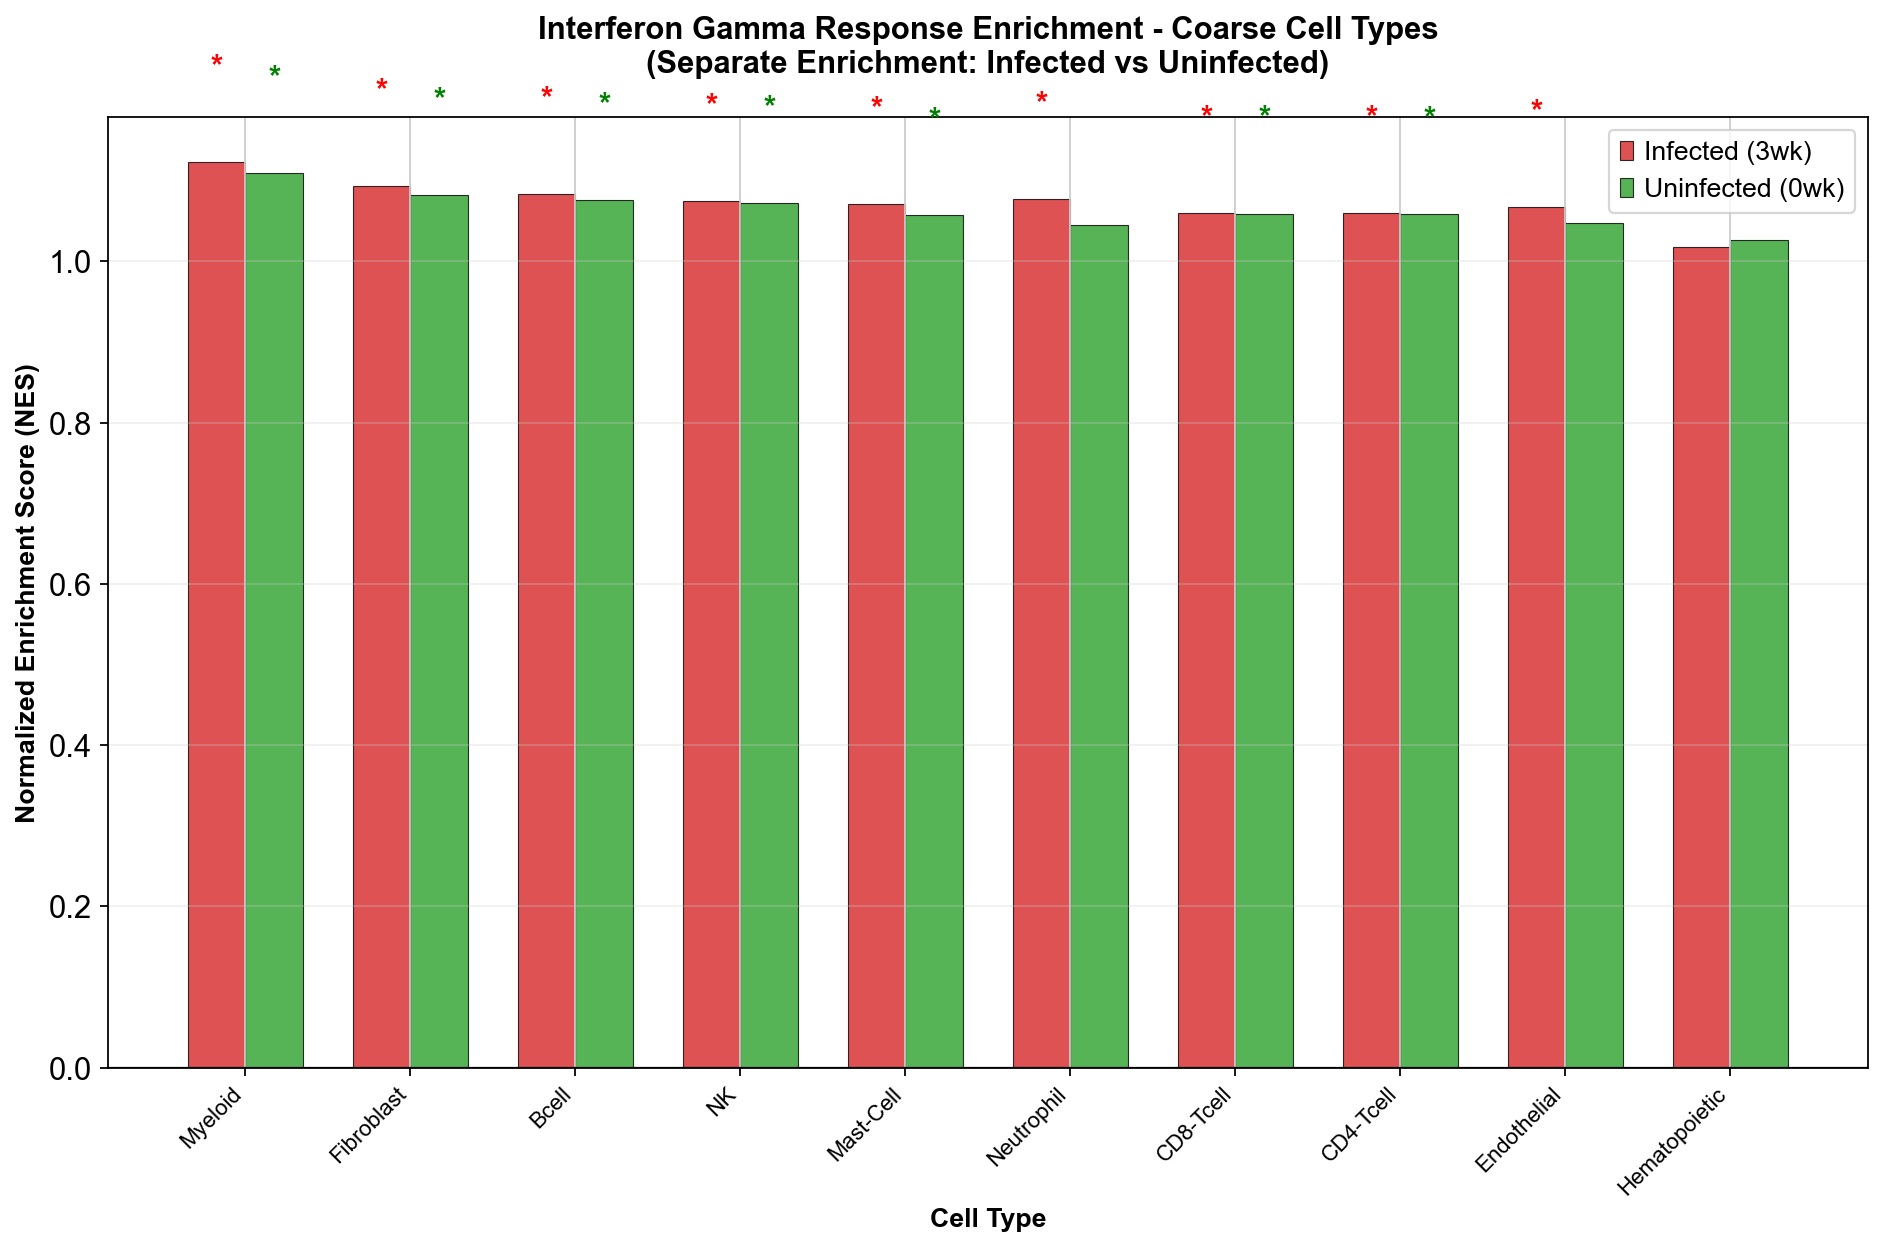

🎨 Creating fine cell types plot...
✅ Saved figure: interferon_gamma_gsea_fine_CORRECTED.png


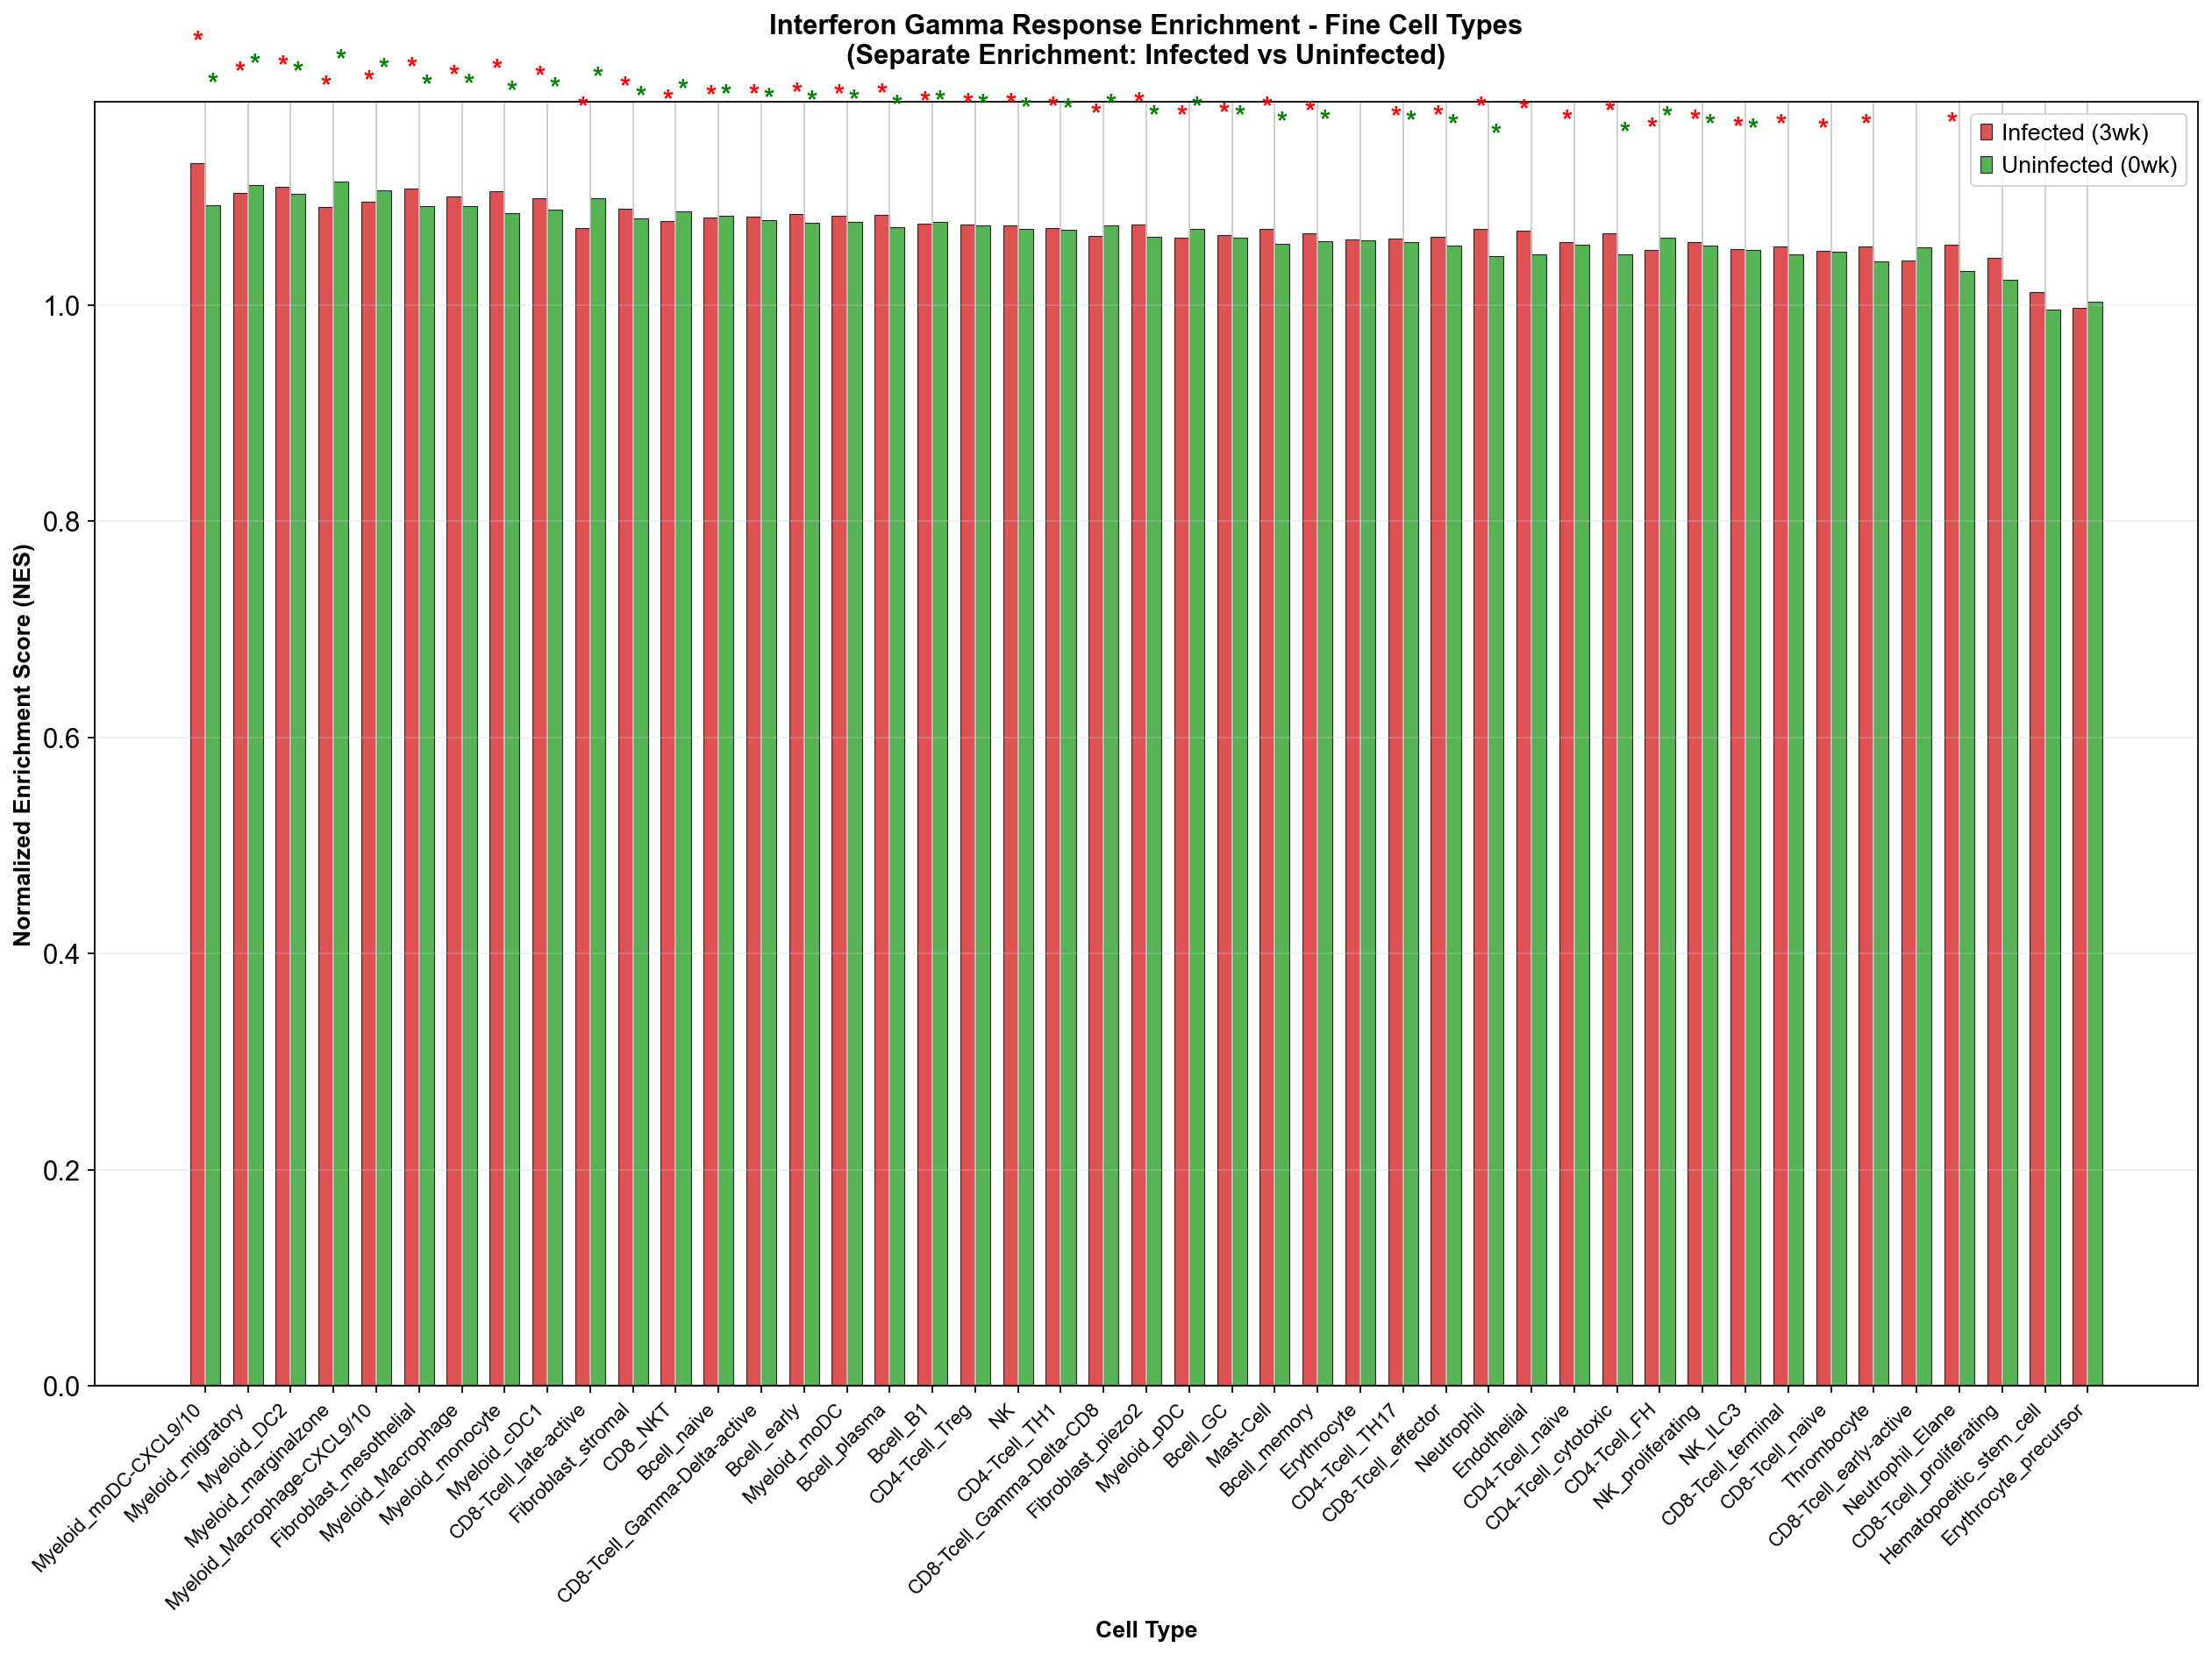


💾 SAVING CORRECTED RESULTS
✅ Saved coarse results: interferon_gamma_gsea_coarse_CORRECTED.csv
✅ Saved fine results: interferon_gamma_gsea_fine_CORRECTED.csv

🎉 CORRECTED ANALYSIS COMPLETE!


In [54]:
# CORRECTED plotting function for two bars per cell type
def plot_interferon_gsea_separate_conditions(results_df, title, figsize=(14, 8), save_path=None):
    """
    Create bar plot with two bars per cell type (infected vs uninfected)
    """
    
    if len(results_df) == 0:
        print(f"No results to plot for {title}")
        return None
    
    # Sort by average NES for better visualization
    results_df['avg_nes'] = (results_df['infected_nes'] + results_df['uninfected_nes']) / 2
    plot_data = results_df.sort_values('avg_nes', ascending=False).copy()
    
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Set up positions for grouped bars
    x_pos = np.arange(len(plot_data))
    width = 0.35
    
    # Create bars
    infected_bars = ax.bar(x_pos - width/2, plot_data['infected_nes'], width, 
                          label='Infected (3wk)', color='#d62728', alpha=0.8, edgecolor='black', linewidth=0.5)
    uninfected_bars = ax.bar(x_pos + width/2, plot_data['uninfected_nes'], width,
                           label='Uninfected (0wk)', color='#2ca02c', alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # Customize plot
    ax.set_xlabel('Cell Type', fontsize=12, fontweight='bold')
    ax.set_ylabel('Normalized Enrichment Score (NES)', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(plot_data['celltype'], rotation=45, ha='right', fontsize=10)
    
    # Add horizontal line at zero
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    
    # Add significance indicators
    for i, (idx, row) in enumerate(plot_data.iterrows()):
        # Infected significance
        if row['infected_fdr'] < 0.05:
            y_pos = row['infected_nes'] + 0.1 if row['infected_nes'] > 0 else row['infected_nes'] - 0.1
            ax.text(i - width/2, y_pos, '*', ha='center', va='bottom' if row['infected_nes'] > 0 else 'top',
                   fontsize=14, fontweight='bold', color='red')
        
        # Uninfected significance  
        if row['uninfected_fdr'] < 0.05:
            y_pos = row['uninfected_nes'] + 0.1 if row['uninfected_nes'] > 0 else row['uninfected_nes'] - 0.1
            ax.text(i + width/2, y_pos, '*', ha='center', va='bottom' if row['uninfected_nes'] > 0 else 'top',
                   fontsize=14, fontweight='bold', color='green')
    
    # Add grid and legend
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(loc='best', fontsize=12)
    
    plt.tight_layout()
    
    # Save if requested
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✅ Saved figure: {save_path}")
    
    plt.show()
    return fig

# Run CORRECTED GSEA analysis for COARSE cell types
print("🔥 RUNNING CORRECTED GSEA ANALYSIS - COARSE CELL TYPES")
print("==================================================")

coarse_celltypes = adata_sc.obs['coarse_redo'].unique()
print(f"✓ Found {len(coarse_celltypes)} coarse cell types")
print(f"   Cell types: {list(coarse_celltypes)}")

coarse_results_corrected = []
for celltype in coarse_celltypes:
    if pd.notna(celltype):
        result = run_gsea_for_celltype_separate_conditions(adata_sc, 
                                                         celltype_col='coarse_redo', 
                                                         celltype_name=celltype,
                                                         gene_set_dict=interferon_gamma_genes)
        if result is not None:
            coarse_results_corrected.append(result)

if len(coarse_results_corrected) > 0:
    coarse_df_corrected = pd.DataFrame(coarse_results_corrected)
    print(f"\n✅ COARSE ANALYSIS COMPLETE")
    print(f"✅ Successfully analyzed {len(coarse_df_corrected)} cell types")
else:
    print(f"\n❌ No successful GSEA results for coarse cell types")
    coarse_df_corrected = pd.DataFrame()

# Run CORRECTED GSEA analysis for FINE cell types  
print("\n🔥 RUNNING CORRECTED GSEA ANALYSIS - FINE CELL TYPES")
print("==================================================")

fine_celltypes = adata_sc.obs['celltypes_redo'].unique()
print(f"✓ Found {len(fine_celltypes)} fine cell types")

fine_results_corrected = []
for celltype in fine_celltypes:
    if pd.notna(celltype):
        result = run_gsea_for_celltype_separate_conditions(adata_sc, 
                                                         celltype_col='celltypes_redo', 
                                                         celltype_name=celltype,
                                                         gene_set_dict=interferon_gamma_genes)
        if result is not None:
            fine_results_corrected.append(result)

if len(fine_results_corrected) > 0:
    fine_df_corrected = pd.DataFrame(fine_results_corrected)
    print(f"\n✅ FINE ANALYSIS COMPLETE")
    print(f"✅ Successfully analyzed {len(fine_df_corrected)} cell types")
else:
    print(f"\n❌ No successful GSEA results for fine cell types")
    fine_df_corrected = pd.DataFrame()

# Create the CORRECTED plots
print("\n📊 CREATING CORRECTED PLOTS")
print("==================================================")

# Plot coarse cell types
if len(coarse_df_corrected) > 0:
    print("🎨 Creating coarse cell types plot...")
    coarse_fig = plot_interferon_gsea_separate_conditions(
        coarse_df_corrected, 
        title="Interferon Gamma Response Enrichment - Coarse Cell Types\n(Separate Enrichment: Infected vs Uninfected)",
        figsize=(12, 8),
        save_path="interferon_gamma_gsea_coarse_CORRECTED.png"
    )

# Plot fine cell types  
if len(fine_df_corrected) > 0:
    print("🎨 Creating fine cell types plot...")
    fine_fig = plot_interferon_gsea_separate_conditions(
        fine_df_corrected, 
        title="Interferon Gamma Response Enrichment - Fine Cell Types\n(Separate Enrichment: Infected vs Uninfected)",
        figsize=(16, 12),
        save_path="interferon_gamma_gsea_fine_CORRECTED.png"
    )

# Save corrected results
print("\n💾 SAVING CORRECTED RESULTS")
print("==================================================")

if len(coarse_df_corrected) > 0:
    coarse_df_corrected.to_csv('interferon_gamma_gsea_coarse_CORRECTED.csv', index=False)
    print(f"✅ Saved coarse results: interferon_gamma_gsea_coarse_CORRECTED.csv")

if len(fine_df_corrected) > 0:
    fine_df_corrected.to_csv('interferon_gamma_gsea_fine_CORRECTED.csv', index=False)
    print(f"✅ Saved fine results: interferon_gamma_gsea_fine_CORRECTED.csv")

print("\n🎉 CORRECTED ANALYSIS COMPLETE!")

In [55]:
# BROAD GSEA ANALYSIS: All Hallmark Pathways - Infected vs Uninfected
print("🔥 BROAD GSEA ANALYSIS - ALL HALLMARK PATHWAYS")
print("=" * 60)
print("Comparing: All Infected (3wk) vs All Uninfected (0wk) cells")
print("=" * 60)

# Check conditions
infected_count = sum(adata_sc.obs['timepoint'] == '3wk')
uninfected_count = sum(adata_sc.obs['timepoint'] == '0wk')
print(f"📊 Total cells - Infected: {infected_count:,}, Uninfected: {uninfected_count:,}")

# Perform differential expression analysis: infected vs uninfected
print("\n🧬 Running differential expression analysis...")
sc.tl.rank_genes_groups(adata_sc, 
                       groupby='timepoint',
                       groups=['3wk'],  # infected
                       reference='0wk',  # uninfected
                       method='wilcoxon',
                       key_added='infected_vs_uninfected')

# Extract DE results
de_results = sc.get.rank_genes_groups_df(adata_sc, group='3wk', key='infected_vs_uninfected')
print(f"✅ Found {len(de_results)} genes in DE analysis")

# Create ranked gene list for GSEA
de_clean = de_results.dropna(subset=['logfoldchanges']).copy()
de_clean['rank_metric'] = de_clean['logfoldchanges'] + np.random.normal(0, 1e-6, len(de_clean))
gene_ranking = de_clean.set_index('names')['rank_metric'].sort_values(ascending=False)
gene_ranking = gene_ranking[~gene_ranking.index.duplicated(keep='first')]

print(f"📈 Using {len(gene_ranking)} genes for GSEA")
print(f"   Top upregulated: {gene_ranking.head(3).index.tolist()}")
print(f"   Top downregulated: {gene_ranking.tail(3).index.tolist()}")

# Load ALL mouse hallmark gene sets (we already have this)
print(f"\n🎯 Using all {len(mouse_hallmark)} mouse hallmark gene sets")

# Run GSEA with all hallmark pathways
print("\n⚡ Running GSEA with all hallmark pathways...")
gsea_results_broad = gp.prerank(
    rnk=gene_ranking,
    gene_sets=mouse_hallmark,  # All hallmark gene sets
    permutation_num=1000,
    outdir=None,
    seed=42,
    verbose=True
)

print("✅ GSEA analysis complete!")

# Extract and format results
if hasattr(gsea_results_broad, 'res2d') and len(gsea_results_broad.res2d) > 0:
    results_df = gsea_results_broad.res2d.copy()
    
    # Clean up pathway names and sort by NES
    results_df = results_df.sort_values('NES', ascending=False)
    
    print(f"\n📊 GSEA RESULTS SUMMARY")
    print("=" * 50)
    print(f"Total pathways analyzed: {len(results_df)}")
    print(f"Significantly enriched in INFECTED (FDR < 0.05): {sum((results_df['FDR q-val'] < 0.05) & (results_df['NES'] > 0))}")
    print(f"Significantly enriched in UNINFECTED (FDR < 0.05): {sum((results_df['FDR q-val'] < 0.05) & (results_df['NES'] < 0))}")
    
    print(f"\n🔝 TOP 10 PATHWAYS ENRICHED IN INFECTED:")
    top_infected = results_df[results_df['NES'] > 0].head(10)
    for idx, row in top_infected.iterrows():
        sig = "*" if row['FDR q-val'] < 0.05 else ""
        print(f"   {row['Term']:<35} | NES: {row['NES']:>6.2f} | FDR: {row['FDR q-val']:>6.3f} {sig}")
    
    print(f"\n🔻 TOP 10 PATHWAYS ENRICHED IN UNINFECTED:")
    top_uninfected = results_df[results_df['NES'] < 0].tail(10)
    for idx, row in top_uninfected.iterrows():
        sig = "*" if row['FDR q-val'] < 0.05 else ""
        print(f"   {row['Term']:<35} | NES: {row['NES']:>6.2f} | FDR: {row['FDR q-val']:>6.3f} {sig}")

else:
    print("❌ No GSEA results generated")
    results_df = pd.DataFrame()

🔥 BROAD GSEA ANALYSIS - ALL HALLMARK PATHWAYS
Comparing: All Infected (3wk) vs All Uninfected (0wk) cells
📊 Total cells - Infected: 28,692, Uninfected: 31,994

🧬 Running differential expression analysis...
ranking genes
    finished: added to `.uns['infected_vs_uninfected']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:54)


2025-07-09 11:51:08,188 [INFO] Parsing data files for GSEA.............................
2025-07-09 11:51:08,218 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-07-09 11:51:08,220 [INFO] 0050 gene_sets used for further statistical testing.....
2025-07-09 11:51:08,220 [INFO] Start to run GSEA...Might take a while..................
2025-07-09 11:51:08,225 [INFO] Genes are converted to uppercase.


✅ Found 32984 genes in DE analysis
📈 Using 32984 genes for GSEA
   Top upregulated: ['Btnl6', 'Try4', 'Cpa1']
   Top downregulated: ['Hmha1', 'PISD', 'Gnb2l1']

🎯 Using all 50 mouse hallmark gene sets

⚡ Running GSEA with all hallmark pathways...


2025-07-09 11:51:11,041 [INFO] Congratulations. GSEApy runs successfully................



✅ GSEA analysis complete!

📊 GSEA RESULTS SUMMARY
Total pathways analyzed: 50
Significantly enriched in INFECTED (FDR < 0.05): 0
Significantly enriched in UNINFECTED (FDR < 0.05): 0

🔝 TOP 10 PATHWAYS ENRICHED IN INFECTED:
   Inflammatory Response               | NES:   1.12 | FDR:  1.000 
   Coagulation                         | NES:   1.12 | FDR:  1.000 
   Wnt-beta Catenin Signaling          | NES:   1.04 | FDR:  1.000 
   Allograft Rejection                 | NES:   1.00 | FDR:  1.000 
   G2-M Checkpoint                     | NES:   1.00 | FDR:  1.000 
   Complement                          | NES:   0.99 | FDR:  1.000 
   Mitotic Spindle                     | NES:   0.98 | FDR:  1.000 
   IL-2/STAT5 Signaling                | NES:   0.92 | FDR:  1.000 
   TNF-alpha Signaling via NF-kB       | NES:   0.90 | FDR:  1.000 
   Interferon Gamma Response           | NES:   0.87 | FDR:  1.000 

🔻 TOP 10 PATHWAYS ENRICHED IN UNINFECTED:
   Oxidative Phosphorylation           | NES:  -0.64 |

🔥 INFLAMMATORY RESPONSE ANALYSIS - COARSE & FINE CELL TYPES
✓ Using Inflammatory Response gene set: 200 genes
✓ First 10 genes: ['IL1R1', 'EREG', 'MARCO', 'TNFSF9', 'VIP', 'SLAMF1', 'SGMS2', 'IFITM1', 'AQP9', 'SERPINE1']

🔥 RUNNING INFLAMMATORY RESPONSE - COARSE CELL TYPES
  🔍 Analyzing Hematopoietic...
    📊 Cells - Infected: 1836, Uninfected: 2254
  🔍 Analyzing Myeloid...
    📊 Cells - Infected: 7943, Uninfected: 5225
  🔍 Analyzing CD8-Tcell...
    📊 Cells - Infected: 7536, Uninfected: 3704
  🔍 Analyzing CD4-Tcell...
    📊 Cells - Infected: 5011, Uninfected: 3993
  🔍 Analyzing NK...
    📊 Cells - Infected: 1505, Uninfected: 1912
  🔍 Analyzing Neutrophil...
    📊 Cells - Infected: 434, Uninfected: 93
  🔍 Analyzing Bcell...
    📊 Cells - Infected: 3807, Uninfected: 14335
  🔍 Analyzing Mast-Cell...
    📊 Cells - Infected: 271, Uninfected: 121
  🔍 Analyzing Endothelial...
    📊 Cells - Infected: 181, Uninfected: 207
  🔍 Analyzing Fibroblast...
    📊 Cells - Infected: 168, Uninfected: 150

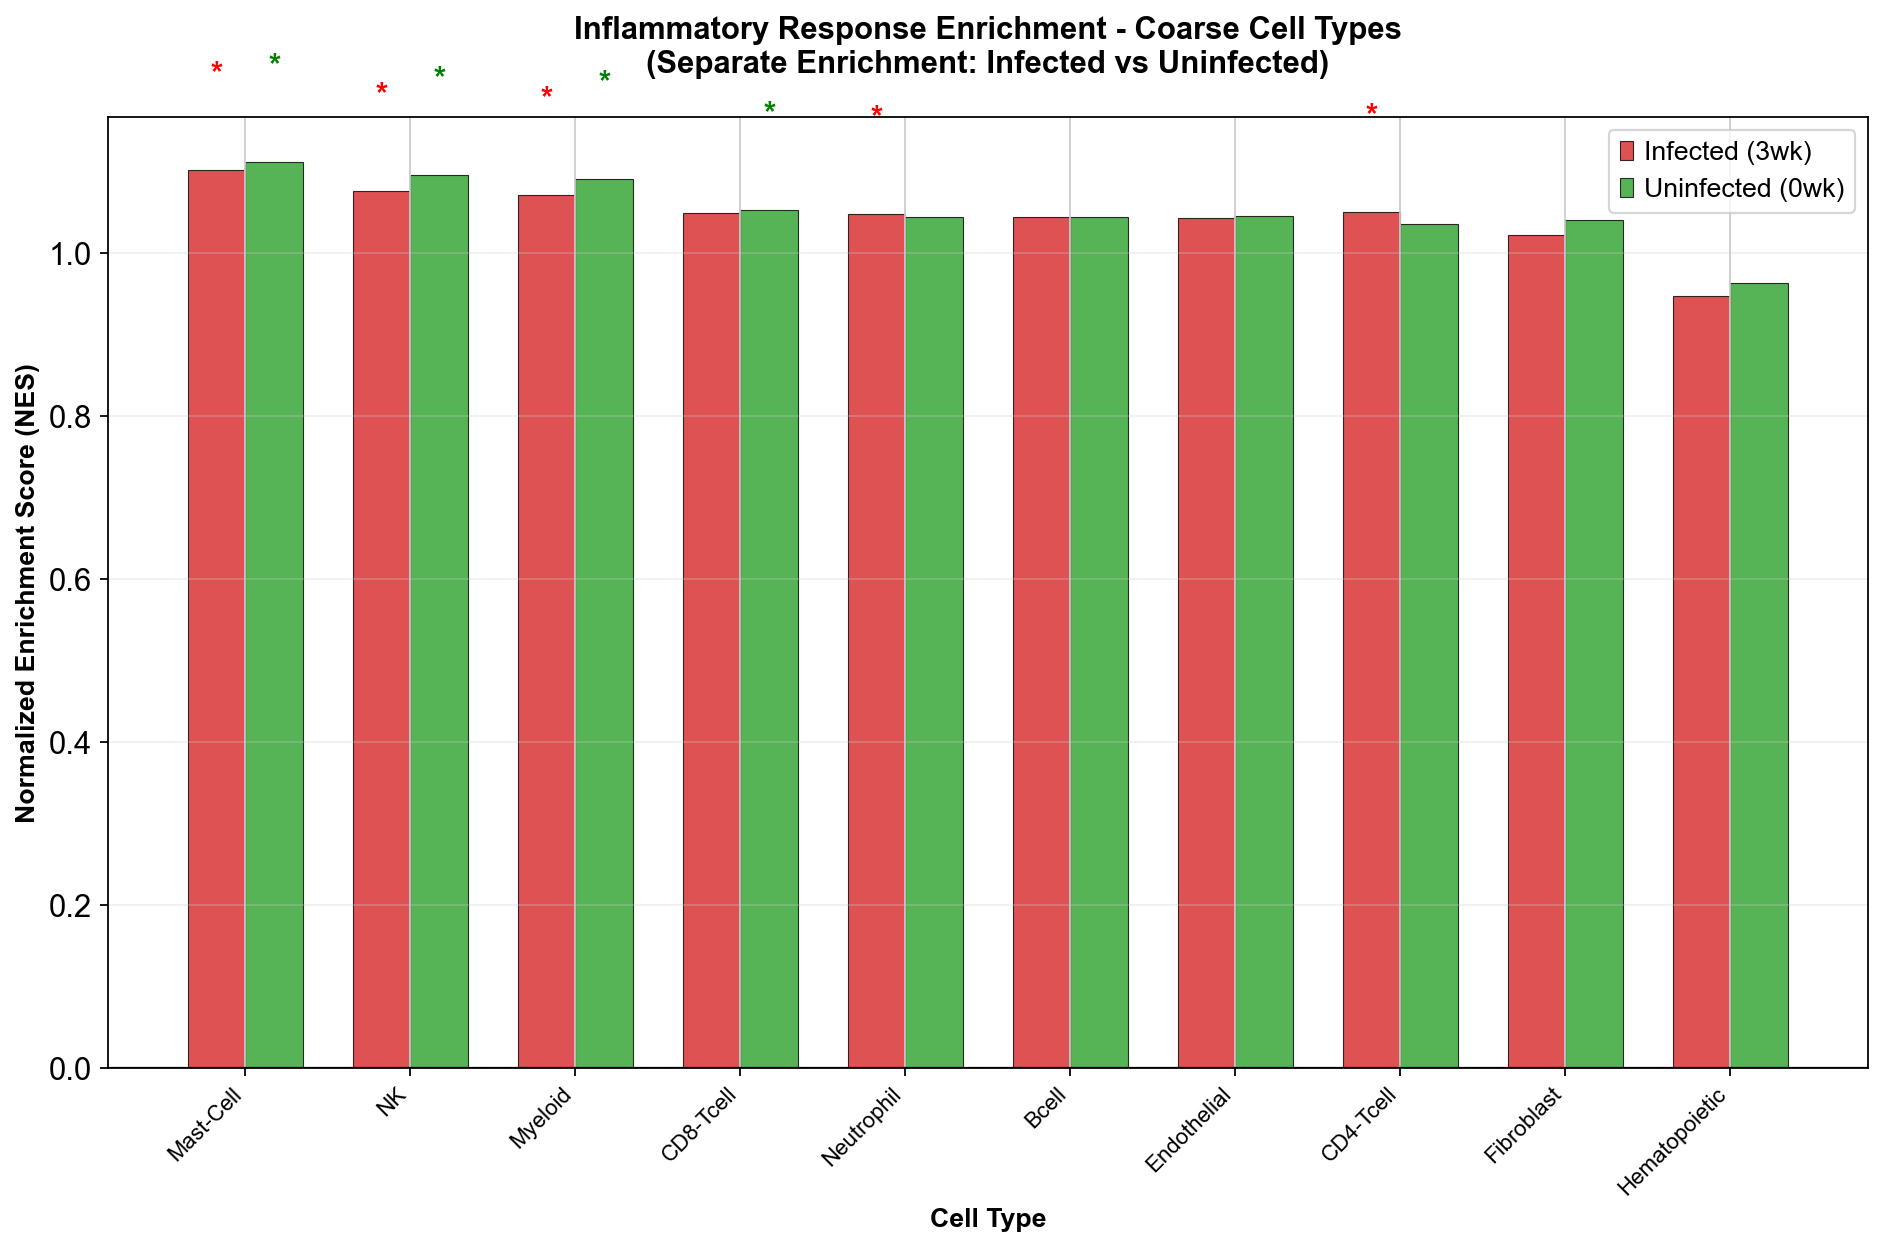

🎨 Creating fine cell types plot...
✅ Saved figure: inflammatory_response_fine_celltypes.png


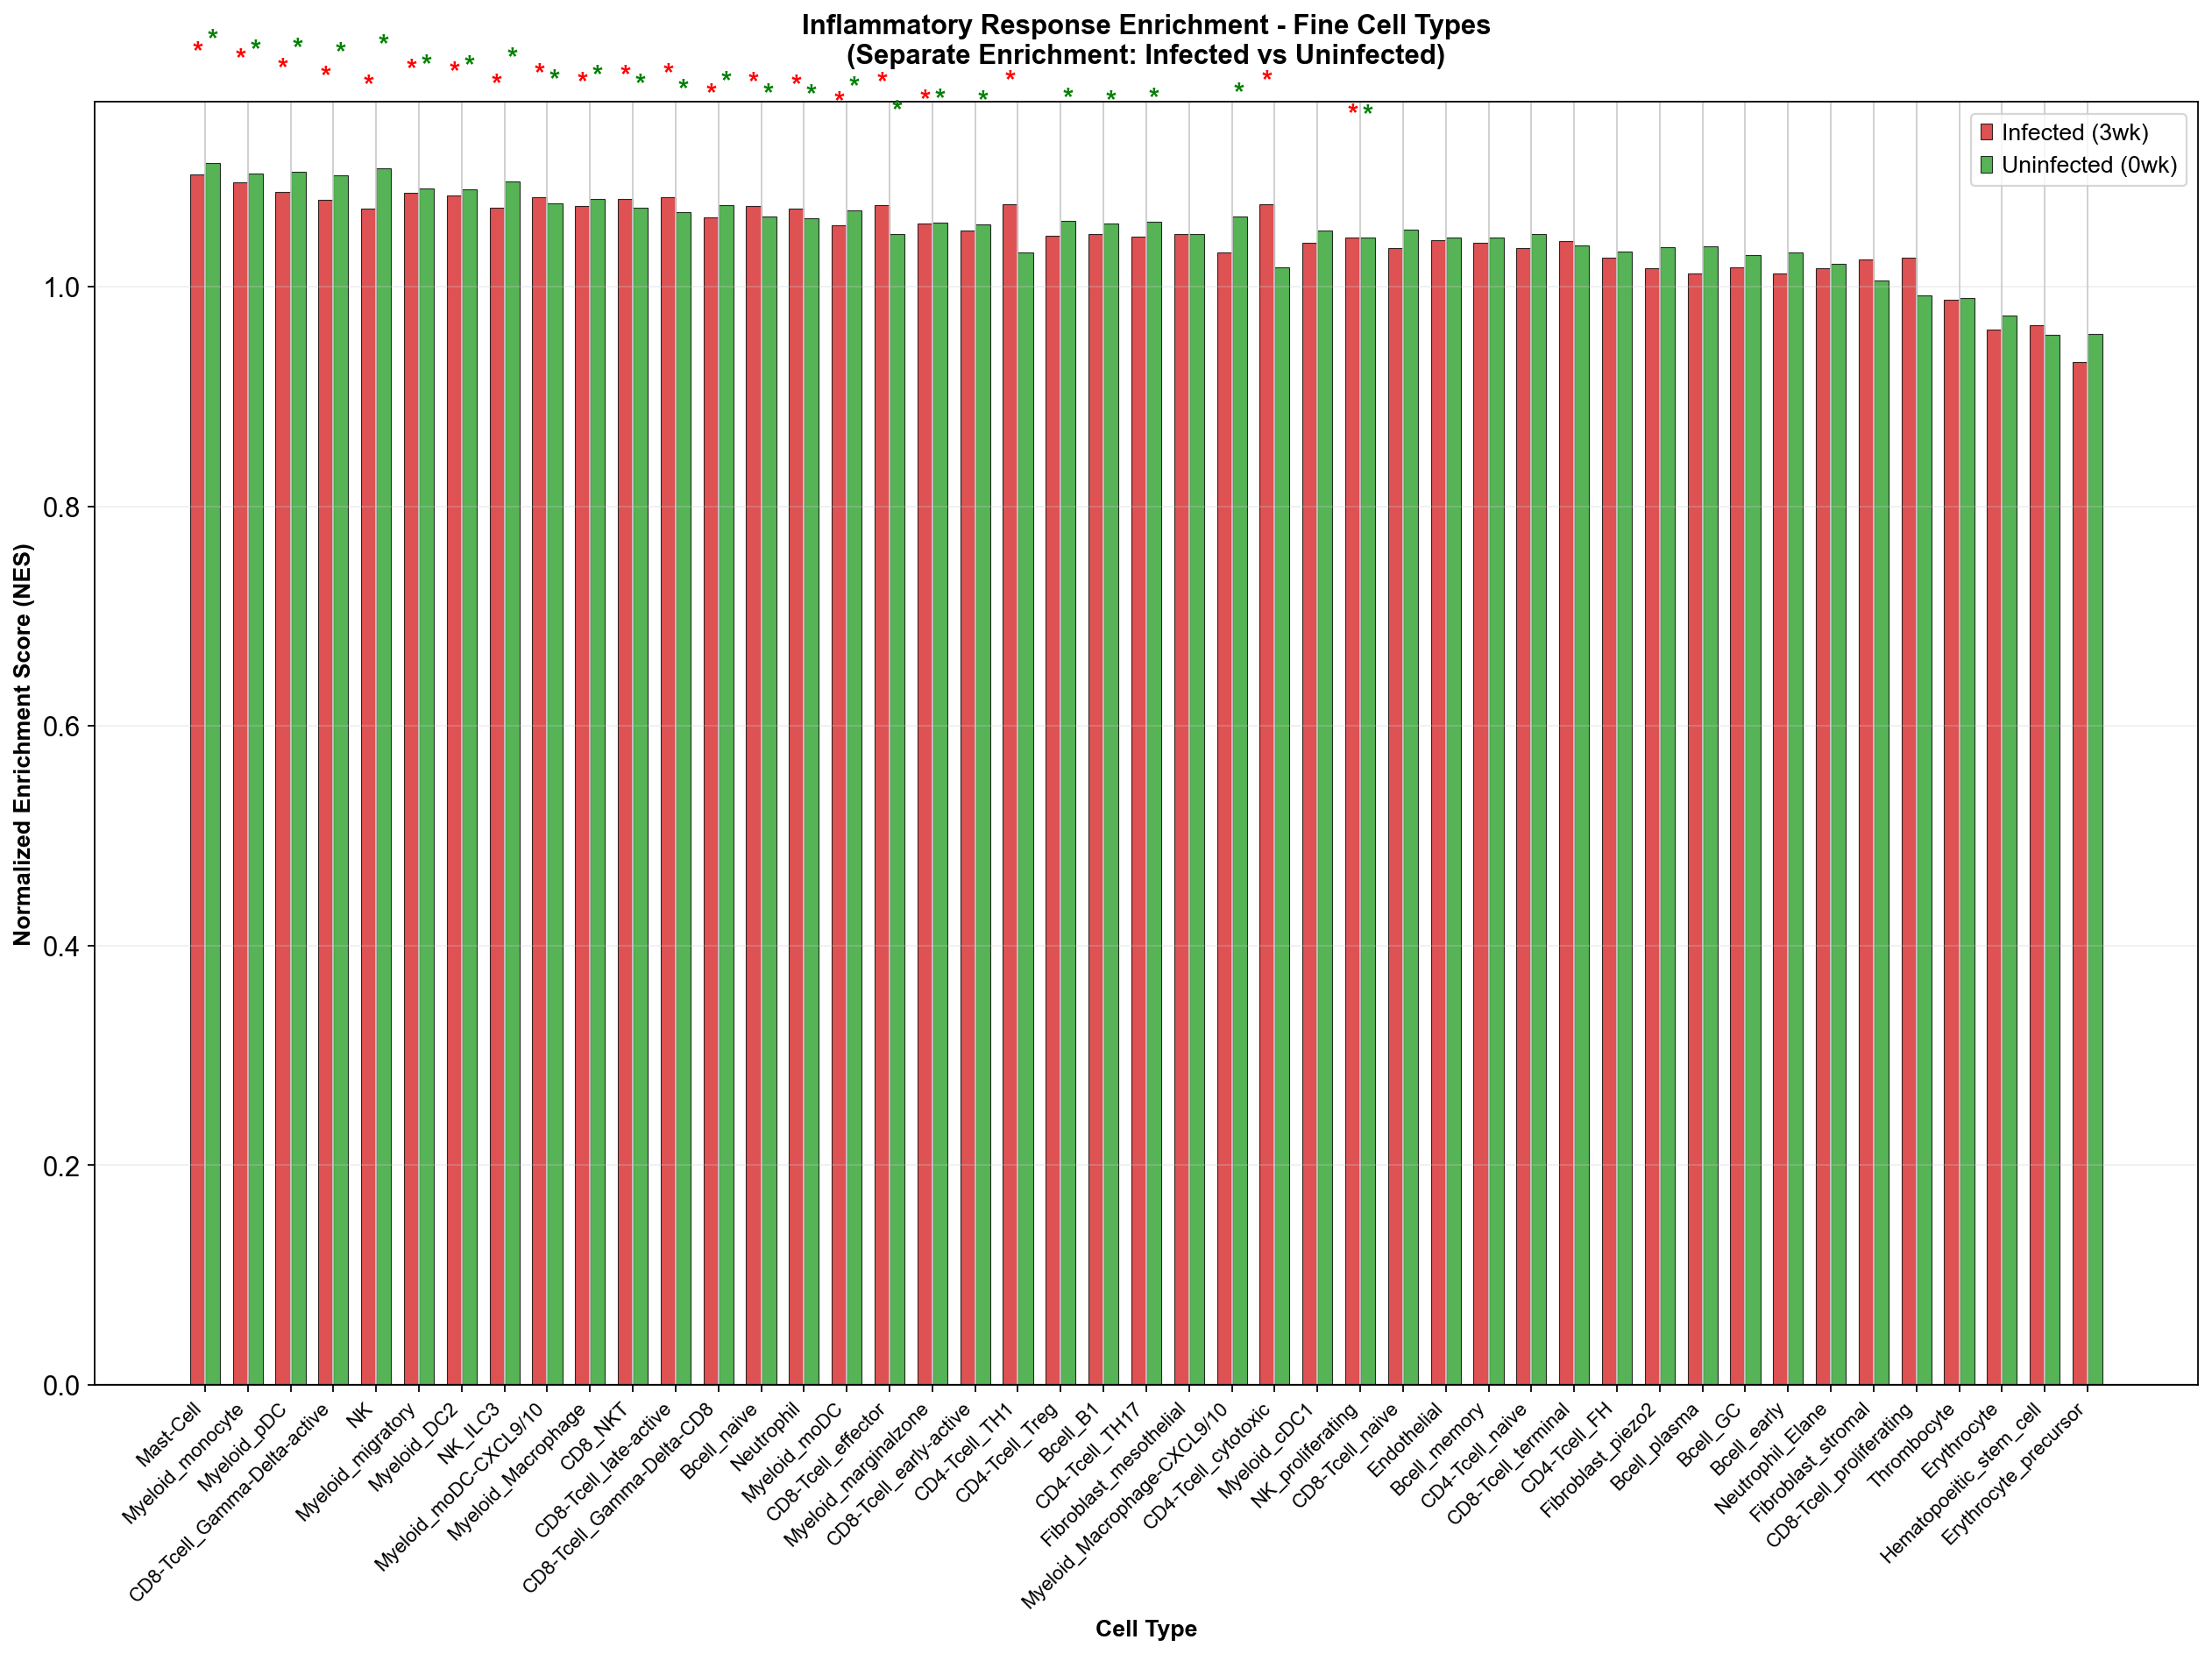


💾 SAVING INFLAMMATORY RESPONSE RESULTS
✅ Saved: inflammatory_response_coarse_results.csv
✅ Saved: inflammatory_response_fine_results.csv

📈 TOP INFLAMMATORY RESPONSE DIFFERENCES (COARSE):
        celltype  infected_nes  uninfected_nes  difference
3      CD4-Tcell         1.050           1.036       0.014
5     Neutrophil         1.048           1.044       0.004
6          Bcell         1.044           1.044      -0.000
8    Endothelial         1.042           1.045      -0.002
2      CD8-Tcell         1.049           1.052      -0.004
7      Mast-Cell         1.102           1.111      -0.010
0  Hematopoietic         0.947           0.962      -0.015
9     Fibroblast         1.021           1.040      -0.019
4             NK         1.076           1.096      -0.020
1        Myeloid         1.071           1.091      -0.020

🎉 INFLAMMATORY RESPONSE ANALYSIS COMPLETE!


In [56]:
# INFLAMMATORY RESPONSE ANALYSIS - Same approach as interferon
print("🔥 INFLAMMATORY RESPONSE ANALYSIS - COARSE & FINE CELL TYPES")
print("=" * 70)

# Extract inflammatory response gene set
inflammatory_genes = {'Inflammatory Response': mouse_hallmark['Inflammatory Response']}
print(f"✓ Using Inflammatory Response gene set: {len(inflammatory_genes['Inflammatory Response'])} genes")
print(f"✓ First 10 genes: {inflammatory_genes['Inflammatory Response'][:10]}")

# Run analysis for COARSE cell types
print("\n🔥 RUNNING INFLAMMATORY RESPONSE - COARSE CELL TYPES")
print("=" * 60)

coarse_inflammatory_results = []
for celltype in adata_sc.obs['coarse_redo'].unique():
    if pd.notna(celltype):
        result = run_gsea_for_celltype_separate_conditions(adata_sc, 
                                                         celltype_col='coarse_redo', 
                                                         celltype_name=celltype,
                                                         gene_set_dict=inflammatory_genes)
        if result is not None:
            coarse_inflammatory_results.append(result)

if len(coarse_inflammatory_results) > 0:
    coarse_inflammatory_df = pd.DataFrame(coarse_inflammatory_results)
    print(f"\n✅ Successfully analyzed {len(coarse_inflammatory_df)} coarse cell types")
else:
    coarse_inflammatory_df = pd.DataFrame()

# Run analysis for FINE cell types
print("\n🔥 RUNNING INFLAMMATORY RESPONSE - FINE CELL TYPES")
print("=" * 60)

fine_inflammatory_results = []
for celltype in adata_sc.obs['celltypes_redo'].unique():
    if pd.notna(celltype):
        result = run_gsea_for_celltype_separate_conditions(adata_sc, 
                                                         celltype_col='celltypes_redo', 
                                                         celltype_name=celltype,
                                                         gene_set_dict=inflammatory_genes)
        if result is not None:
            fine_inflammatory_results.append(result)

if len(fine_inflammatory_results) > 0:
    fine_inflammatory_df = pd.DataFrame(fine_inflammatory_results)
    print(f"\n✅ Successfully analyzed {len(fine_inflammatory_df)} fine cell types")
else:
    fine_inflammatory_df = pd.DataFrame()

# Plot COARSE cell types
print("\n📊 CREATING INFLAMMATORY RESPONSE PLOTS")
print("=" * 50)

if len(coarse_inflammatory_df) > 0:
    print("🎨 Creating coarse cell types plot...")
    coarse_inflam_fig = plot_interferon_gsea_separate_conditions(
        coarse_inflammatory_df, 
        title="Inflammatory Response Enrichment - Coarse Cell Types\n(Separate Enrichment: Infected vs Uninfected)",
        figsize=(12, 8),
        save_path="inflammatory_response_coarse_celltypes.png"
    )

# Plot FINE cell types  
if len(fine_inflammatory_df) > 0:
    print("🎨 Creating fine cell types plot...")
    fine_inflam_fig = plot_interferon_gsea_separate_conditions(
        fine_inflammatory_df, 
        title="Inflammatory Response Enrichment - Fine Cell Types\n(Separate Enrichment: Infected vs Uninfected)",
        figsize=(16, 12),
        save_path="inflammatory_response_fine_celltypes.png"
    )

# Save results
print("\n💾 SAVING INFLAMMATORY RESPONSE RESULTS")
print("=" * 50)

if len(coarse_inflammatory_df) > 0:
    coarse_inflammatory_df.to_csv('inflammatory_response_coarse_results.csv', index=False)
    print(f"✅ Saved: inflammatory_response_coarse_results.csv")

if len(fine_inflammatory_df) > 0:
    fine_inflammatory_df.to_csv('inflammatory_response_fine_results.csv', index=False)
    print(f"✅ Saved: inflammatory_response_fine_results.csv")

# Compare top differences
if len(coarse_inflammatory_df) > 0:
    print(f"\n📈 TOP INFLAMMATORY RESPONSE DIFFERENCES (COARSE):")
    coarse_inflammatory_df['difference'] = coarse_inflammatory_df['infected_nes'] - coarse_inflammatory_df['uninfected_nes']
    top_diff = coarse_inflammatory_df.sort_values('difference', ascending=False)
    print(top_diff[['celltype', 'infected_nes', 'uninfected_nes', 'difference']].round(3))

print("\n🎉 INFLAMMATORY RESPONSE ANALYSIS COMPLETE!")

In [4]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# Focus on CD8 T cells
cd8_subtypes = [
    'CD8-Tcell_early-active', 
    'CD8-Tcell_late-active',
    'CD8-Tcell_proliferating',
]

cd8_mask = adata_sc.obs['celltypes_redo'].isin(cd8_subtypes)
adata_cd8 = adata_sc[cd8_mask].copy()

print(f"CD8 T cells: {adata_cd8.shape[0]} cells")

# Get CXCR3 expression and create low/mid/high groups
cxcr3_expr = adata_cd8[:, 'Cxcr3'].X.toarray().flatten()

# Define tertiles for low/mid/high CXCR3 expression
cxcr3_33rd = np.percentile(cxcr3_expr, 33.33)
cxcr3_66th = np.percentile(cxcr3_expr, 66.67)

print(f"CXCR3 expression tertiles:")
print(f"  Low (0-33rd): 0 to {cxcr3_33rd:.3f}")
print(f"  Mid (33rd-66th): {cxcr3_33rd:.3f} to {cxcr3_66th:.3f}")
print(f"  High (66th-100th): {cxcr3_66th:.3f} to {cxcr3_expr.max():.3f}")

# Assign CXCR3 expression groups
cxcr3_groups = []
for expr in cxcr3_expr:
    if expr <= cxcr3_33rd:
        cxcr3_groups.append('Low')
    elif expr <= cxcr3_66th:
        cxcr3_groups.append('Mid')
    else:
        cxcr3_groups.append('High')

adata_cd8.obs['cxcr3_group'] = cxcr3_groups

print(f"\nCXCR3 group distribution:")
print(adata_cd8.obs['cxcr3_group'].value_counts())

# Check distribution by condition
print(f"\nCXCR3 groups by condition:")
cxcr3_condition_crosstab = pd.crosstab(adata_cd8.obs['cxcr3_group'], 
                                       adata_cd8.obs['timepoint'], 
                                       normalize='columns') * 100
print(cxcr3_condition_crosstab.round(1))

# Define PF4/CXCL4 signaling signature genes based on the paper
# These should be UPREGULATED by PF4-CXCR3 signaling (suppressive/regulatory)
pf4_upregulated_genes = [
    'Pdcd1',    # PD-1 (exhaustion)
    'Havcr2',   # TIM-3 (exhaustion)
    'Lag3',     # LAG-3 (exhaustion) 
    'Tigit',    # TIGIT (exhaustion)
    'Ctla4',    # CTLA-4 (inhibitory)
    'Il10',     # IL-10 (immunosuppressive)
    'Tgfb1',    # TGF-β1 (immunosuppressive)
    'Foxp3',    # Treg transcription factor
    'Ikzf2',    # Helios (Treg marker)
    'Cd39',     # Ectonucleotidase (Treg)
    'Nt5e',     # CD73 (adenosine pathway)
    'Adora2a',  # Adenosine receptor
    'Entpd1'    # CD39 (alternative name)
]

# These should be DOWNREGULATED by PF4-CXCR3 signaling (effector functions)
pf4_downregulated_genes = [
    'Ifng',     # IFN-γ (Th1 effector)
    'Tnf',      # TNF-α (inflammatory)
    'Il2',      # IL-2 (T cell growth)
    'Gzmb',     # Granzyme B (cytotoxicity)
    'Gzma',     # Granzyme A (cytotoxicity)
    'Prf1',     # Perforin (cytotoxicity)
    'Cd69',     # Early activation
    'Cd25',     # IL-2 receptor (activation)
    'Tbx21',    # T-bet (Th1 transcription factor)
    'Eomes',    # Eomesodermin (effector T cell TF)
    'Klrg1',    # KLRG1 (terminal differentiation)
    'Cx3cr1',   # CX3CR1 (effector migration)
    'S1pr1',    # S1P receptor (tissue exit)
    'Ccr7',     # CCR7 (lymph node homing)
    'Sell'      # L-selectin (lymph node entry)
]

# Check which genes are available in the dataset
available_upregulated = [gene for gene in pf4_upregulated_genes if gene in adata_cd8.var_names]
available_downregulated = [gene for gene in pf4_downregulated_genes if gene in adata_cd8.var_names]

print(f"\nAvailable PF4-upregulated genes: {available_upregulated}")
print(f"Available PF4-downregulated genes: {available_downregulated}")

# Analyze gene expression across CXCR3 groups and conditions
def analyze_gene_expression_by_cxcr3_and_condition(gene_list, gene_type):
    print(f"\n=== {gene_type.upper()} GENE ANALYSIS ===")
    
    results = []
    
    for gene in gene_list:
        if gene in adata_cd8.var_names:
            gene_expr = adata_cd8[:, gene].X.toarray().flatten()
            
            # Create analysis dataframe
            gene_df = pd.DataFrame({
                'expression': gene_expr,
                'cxcr3_group': adata_cd8.obs['cxcr3_group'].values,
                'condition': adata_cd8.obs['timepoint'].values
            })
            
            # Calculate means for each group
            group_means = gene_df.groupby(['cxcr3_group', 'condition'])['expression'].mean().unstack()
            
            # Calculate fold changes
            if '0wk' in group_means.columns and '3wk' in group_means.columns:
                fold_changes = {}
                for cxcr3_group in ['Low', 'Mid', 'High']:
                    if cxcr3_group in group_means.index:
                        infected = group_means.loc[cxcr3_group, '3wk']
                        uninfected = group_means.loc[cxcr3_group, '0wk']
                        fc = infected / (uninfected + 1e-6)  # Add small constant
                        fold_changes[cxcr3_group] = fc
                
                # Store results
                results.append({
                    'gene': gene,
                    'gene_type': gene_type,
                    'low_cxcr3_fc': fold_changes.get('Low', np.nan),
                    'mid_cxcr3_fc': fold_changes.get('Mid', np.nan),
                    'high_cxcr3_fc': fold_changes.get('High', np.nan),
                    'low_uninfected': group_means.loc['Low', '0wk'] if 'Low' in group_means.index else np.nan,
                    'low_infected': group_means.loc['Low', '3wk'] if 'Low' in group_means.index else np.nan,
                    'mid_uninfected': group_means.loc['Mid', '0wk'] if 'Mid' in group_means.index else np.nan,
                    'mid_infected': group_means.loc['Mid', '3wk'] if 'Mid' in group_means.index else np.nan,
                    'high_uninfected': group_means.loc['High', '0wk'] if 'High' in group_means.index else np.nan,
                    'high_infected': group_means.loc['High', '3wk'] if 'High' in group_means.index else np.nan
                })
                
                print(f"\n{gene} expression by CXCR3 group and condition:")
                print(group_means.round(3))
                print(f"Fold changes (Infected/Uninfected): {fold_changes}")
    
    return pd.DataFrame(results)

# Analyze both gene sets
upregulated_results = analyze_gene_expression_by_cxcr3_and_condition(available_upregulated, 'upregulated')
downregulated_results = analyze_gene_expression_by_cxcr3_and_condition(available_downregulated, 'downregulated')

# Combine results
all_results = pd.concat([upregulated_results, downregulated_results], ignore_index=True)

# Look for CXCR3-dependent effects
print(f"\n=== CXCR3-DEPENDENT PF4 SIGNALING SIGNATURE ===")
print("Looking for genes that show stronger effects in High CXCR3 cells...")

# For upregulated genes, we expect higher fold changes in High CXCR3 cells
# For downregulated genes, we expect lower fold changes in High CXCR3 cells

cxcr3_dependent_up = upregulated_results[
    (upregulated_results['high_cxcr3_fc'] > upregulated_results['low_cxcr3_fc']) &
    (upregulated_results['high_cxcr3_fc'] > 1.2)  # At least 20% increase
]

cxcr3_dependent_down = downregulated_results[
    (downregulated_results['high_cxcr3_fc'] < downregulated_results['low_cxcr3_fc']) &
    (downregulated_results['high_cxcr3_fc'] < 0.8)  # At least 20% decrease
]

print(f"\nCXCR3-dependent UPREGULATED genes (stronger in High CXCR3):")
if len(cxcr3_dependent_up) > 0:
    print(cxcr3_dependent_up[['gene', 'low_cxcr3_fc', 'mid_cxcr3_fc', 'high_cxcr3_fc']].round(3))
else:
    print("None found")

print(f"\nCXCR3-dependent DOWNREGULATED genes (stronger in High CXCR3):")
if len(cxcr3_dependent_down) > 0:
    print(cxcr3_dependent_down[['gene', 'low_cxcr3_fc', 'mid_cxcr3_fc', 'high_cxcr3_fc']].round(3))
else:
    print("None found")

# Calculate PF4 signaling signature score
print(f"\n=== PF4 SIGNALING SIGNATURE SCORE ===")

def calculate_signature_score(adata, up_genes, down_genes):
    """Calculate a signature score based on upregulated and downregulated genes"""
    up_available = [g for g in up_genes if g in adata.var_names]
    down_available = [g for g in down_genes if g in adata.var_names]
    
    if len(up_available) == 0 and len(down_available) == 0:
        return np.zeros(adata.n_obs)
    
    scores = np.zeros(adata.n_obs)
    
    # Add upregulated genes (positive contribution)
    if len(up_available) > 0:
        up_expr = adata[:, up_available].X.toarray()
        up_score = np.mean(up_expr, axis=1)
        scores += up_score
    
    # Subtract downregulated genes (negative contribution) 
    if len(down_available) > 0:
        down_expr = adata[:, down_available].X.toarray()
        down_score = np.mean(down_expr, axis=1)
        scores -= down_score
    
    return scores

# Calculate signature scores
pf4_signature_scores = calculate_signature_score(adata_cd8, available_upregulated, available_downregulated)
adata_cd8.obs['pf4_signature_score'] = pf4_signature_scores

# Analyze signature scores by CXCR3 group and condition
signature_analysis = pd.DataFrame({
    'pf4_score': pf4_signature_scores,
    'cxcr3_group': adata_cd8.obs['cxcr3_group'].values,
    'condition': adata_cd8.obs['timepoint'].values
})

signature_summary = signature_analysis.groupby(['cxcr3_group', 'condition'])['pf4_score'].agg(['mean', 'std', 'count']).round(3)
print("PF4 signature score by CXCR3 group and condition:")
print(signature_summary)

# Test for significant differences
print(f"\nStatistical tests for PF4 signature differences:")
for cxcr3_group in ['Low', 'Mid', 'High']:
    group_data = signature_analysis[signature_analysis['cxcr3_group'] == cxcr3_group]
    if len(group_data) > 0:
        infected = group_data[group_data['condition'] == '3wk']['pf4_score']
        uninfected = group_data[group_data['condition'] == '0wk']['pf4_score']
        
        if len(infected) > 0 and len(uninfected) > 0:
            stat, pval = mannwhitneyu(infected, uninfected, alternative='two-sided')
            print(f"{cxcr3_group} CXCR3: Infected vs Uninfected p-value = {pval:.2e}")

CD8 T cells: 2366 cells
CXCR3 expression tertiles:
  Low (0-33rd): 0 to 0.000
  Mid (33rd-66th): 0.000 to 0.346
  High (66th-100th): 0.346 to 2.451

CXCR3 group distribution:
cxcr3_group
Low     1493
High     789
Mid       84
Name: count, dtype: int64

CXCR3 groups by condition:
timepoint     0wk   3wk
cxcr3_group            
High         44.9  30.7
Low          52.0  65.7
Mid           3.1   3.6

Available PF4-upregulated genes: ['Pdcd1', 'Havcr2', 'Lag3', 'Tigit', 'Ctla4', 'Il10', 'Tgfb1', 'Foxp3', 'Ikzf2', 'Nt5e', 'Adora2a', 'Entpd1']
Available PF4-downregulated genes: ['Ifng', 'Tnf', 'Il2', 'Gzmb', 'Gzma', 'Prf1', 'Cd69', 'Tbx21', 'Eomes', 'Klrg1', 'Cx3cr1', 'S1pr1', 'Ccr7', 'Sell']

=== UPREGULATED GENE ANALYSIS ===

Pdcd1 expression by CXCR3 group and condition:
condition      0wk    3wk
cxcr3_group              
High         0.004  0.006
Low          0.014  0.011
Mid          0.016  0.019
Fold changes (Infected/Uninfected): {'Low': 0.7959659544949519, 'Mid': 1.1561744156307199, 

/var/folders/qb/hfnm72x95497q4_ptv95pn8r0000gn/T/ipykernel_46242/2612337433.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = gene_df.groupby(['cxcr3_group', 'condition'])['expression'].mean().unstack()
/var/folders/qb/hfnm72x95497q4_ptv95pn8r0000gn/T/ipykernel_46242/2612337433.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = gene_df.groupby(['cxcr3_group', 'condition'])['expression'].mean().unstack()
/var/folders/qb/hfnm72x95497q4_ptv95pn8r0000gn/T/ipykernel_46242/2612337433.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in 


Cx3cr1 expression by CXCR3 group and condition:
condition      0wk    3wk
cxcr3_group              
High         0.027  0.149
Low          0.068  0.324
Mid          0.000  0.217
Fold changes (Infected/Uninfected): {'Low': 4.732959793758264, 'Mid': 216577.55970954895, 'High': 5.576218982840372}

S1pr1 expression by CXCR3 group and condition:
condition      0wk    3wk
cxcr3_group              
High         0.723  0.465
Low          0.863  0.461
Mid          0.547  0.464
Fold changes (Infected/Uninfected): {'Low': 0.5343317680208369, 'Mid': 0.8474740758724307, 'High': 0.64235651651491}

Ccr7 expression by CXCR3 group and condition:
condition      0wk    3wk
cxcr3_group              
High         0.410  0.122
Low          0.492  0.146
Mid          0.380  0.201
Fold changes (Infected/Uninfected): {'Low': 0.29659548718446976, 'Mid': 0.5273954351826744, 'High': 0.2973285343180361}

Sell expression by CXCR3 group and condition:
condition      0wk    3wk
cxcr3_group              
High         

/var/folders/qb/hfnm72x95497q4_ptv95pn8r0000gn/T/ipykernel_46242/2612337433.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = gene_df.groupby(['cxcr3_group', 'condition'])['expression'].mean().unstack()
/var/folders/qb/hfnm72x95497q4_ptv95pn8r0000gn/T/ipykernel_46242/2612337433.py:223: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  signature_summary = signature_analysis.groupby(['cxcr3_group', 'condition'])['pf4_score'].agg(['mean', 'std', 'count']).round(3)


In [8]:
import scanpy as sc
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

print("=== DIFFERENTIAL EXPRESSION ANALYSIS BETWEEN CXCR3 GROUPS ===")
print(f"Analyzing CD8 T cells: {adata_cd8.shape[0]} cells")
print(f"CXCR3 group distribution: {adata_cd8.obs['cxcr3_group'].value_counts()}")

# Focus on infected condition for cleaner comparison
infected_cd8 = adata_cd8[adata_cd8.obs['timepoint'] == '3wk'].copy()
print(f"Infected CD8 cells: {infected_cd8.shape[0]} cells")

# Run differential expression for each CXCR3 group vs others
print(f"\n=== RUNNING DIFFERENTIAL EXPRESSION ANALYSIS ===")

# Set up scanpy for DE analysis
sc.tl.rank_genes_groups(infected_cd8, 
                       groupby='cxcr3_group',
                       groups=['High', 'Mid', 'Low'],
                       method='wilcoxon',
                       key_added='cxcr3_de')

# Extract results for each group
def get_de_results(adata, group_name, key='cxcr3_de', n_genes=None):
    """Extract DE results for a specific group"""
    de_df = sc.get.rank_genes_groups_df(adata, group=group_name, key=key)
    if n_genes:
        de_df = de_df.head(n_genes)
    return de_df

# Get top genes for each CXCR3 group
high_cxcr3_genes = get_de_results(infected_cd8, 'High', n_genes=20)
mid_cxcr3_genes = get_de_results(infected_cd8, 'Mid', n_genes=20)
low_cxcr3_genes = get_de_results(infected_cd8, 'Low', n_genes=20)

print(f"\n=== TOP 10 GENES FOR EACH CXCR3 GROUP ===")

print(f"\nHIGH CXCR3 signature genes (vs Mid+Low):")
print(high_cxcr3_genes[['names', 'logfoldchanges', 'pvals_adj']].head(10).to_string(index=False))

print(f"\nMID CXCR3 signature genes (vs High+Low):")
print(mid_cxcr3_genes[['names', 'logfoldchanges', 'pvals_adj']].head(10).to_string(index=False))

print(f"\nLOW CXCR3 signature genes (vs High+Mid):")
print(low_cxcr3_genes[['names', 'logfoldchanges', 'pvals_adj']].head(10).to_string(index=False))

# Focus on chemokine receptors
print(f"\n=== CHEMOKINE RECEPTOR EXPRESSION ANALYSIS ===")

# List of chemokine receptors to check
chemokine_receptors = [
    'Ccr1', 'Ccr2', 'Ccr3', 'Ccr4', 'Ccr5', 'Ccr6', 'Ccr7', 'Ccr8', 'Ccr9', 'Ccr10',
    'Cxcr1', 'Cxcr2', 'Cxcr3', 'Cxcr4', 'Cxcr5', 'Cxcr6',
    'Cx3cr1', 'Xcr1', 'Ccrl2'
]

# Check which receptors are in the data
available_receptors = [r for r in chemokine_receptors if r in infected_cd8.var_names]
print(f"Available chemokine receptors: {available_receptors}")

# Calculate mean expression for each receptor in each CXCR3 group
receptor_expression = {}

for receptor in available_receptors:
    receptor_expr = infected_cd8[:, receptor].X.toarray().flatten()
    
    receptor_by_group = {}
    for group in ['Low', 'Mid', 'High']:
        group_mask = infected_cd8.obs['cxcr3_group'] == group
        if group_mask.sum() > 0:
            group_expr = receptor_expr[group_mask]
            receptor_by_group[group] = {
                'mean': group_expr.mean(),
                'positive_cells': (group_expr > 0).sum(),
                'total_cells': group_mask.sum(),
                'percent_positive': (group_expr > 0).mean() * 100
            }
    
    receptor_expression[receptor] = receptor_by_group

# Create summary table for chemokine receptors
receptor_df_data = []
for receptor, groups in receptor_expression.items():
    for group, stats in groups.items():
        receptor_df_data.append({
            'receptor': receptor,
            'cxcr3_group': group,
            'mean_expression': stats['mean'],
            'percent_positive': stats['percent_positive'],
            'positive_cells': stats['positive_cells'],
            'total_cells': stats['total_cells']
        })

receptor_df = pd.DataFrame(receptor_df_data)

print(f"\nChemokine receptor expression by CXCR3 group:")
print("=" * 60)

# Show receptors with >5% expression in at least one group
for receptor in available_receptors:
    receptor_data = receptor_df[receptor_df['receptor'] == receptor]
    max_expression = receptor_data['percent_positive'].max()
    
    if max_expression > 5:  # Only show if >5% cells express it
        print(f"\n{receptor}:")
        for _, row in receptor_data.iterrows():
            print(f"  {row['cxcr3_group']} CXCR3: {row['mean_expression']:.3f} mean, "
                  f"{row['percent_positive']:.1f}% positive ({row['positive_cells']}/{row['total_cells']} cells)")

# Statistical comparison of chemokine receptors between groups
print(f"\n=== STATISTICAL COMPARISON OF KEY CHEMOKINE RECEPTORS ===")

key_receptors = ['Ccr7', 'Cx3cr1', 'Cxcr4', 'Cxcr5', 'Ccr5'] # Focus on important ones
key_receptors = [r for r in key_receptors if r in available_receptors]

for receptor in key_receptors:
    print(f"\n{receptor} statistical comparisons:")
    receptor_expr = infected_cd8[:, receptor].X.toarray().flatten()
    
    groups = ['Low', 'Mid', 'High']
    group_data = {}
    
    for group in groups:
        group_mask = infected_cd8.obs['cxcr3_group'] == group
        if group_mask.sum() > 0:
            group_data[group] = receptor_expr[group_mask]
    
    # Pairwise comparisons
    for i, group1 in enumerate(groups):
        for group2 in groups[i+1:]:
            if group1 in group_data and group2 in group_data:
                if len(group_data[group1]) > 0 and len(group_data[group2]) > 0:
                    stat, pval = mannwhitneyu(group_data[group1], group_data[group2], 
                                            alternative='two-sided')
                    mean1 = group_data[group1].mean()
                    mean2 = group_data[group2].mean()
                    fold_change = mean1 / (mean2 + 1e-6)
                    
                    print(f"  {group1} vs {group2}: p={pval:.2e}, "
                          f"FC={fold_change:.2f} ({mean1:.3f} vs {mean2:.3f})")

# Look for functional gene categories in each CXCR3 group
print(f"\n=== FUNCTIONAL CATEGORIES IN TOP DE GENES ===")

functional_categories = {
    'Exhaustion/Inhibitory': ['Pdcd1', 'Havcr2', 'Lag3', 'Tigit', 'Ctla4', 'Cd160', 'Btla'],
    'Activation/Effector': ['Cd69', 'Cd25', 'Il2ra', 'Ifng', 'Tnf', 'Il2'],
    'Cytotoxicity': ['Gzmb', 'Gzma', 'Prf1', 'Gnly'],
    'Migration/Homing': ['Ccr7', 'Sell', 'S1pr1', 'Cx3cr1', 'Klrg1'],
    'Transcription Factors': ['Tbx21', 'Eomes', 'Tcf7', 'Batf', 'Prdm1', 'Foxp3'],
    'Metabolism': ['Glut1', 'Hk2', 'Ldha', 'Pkm', 'Pfkfb3']
}

for category, genes in functional_categories.items():
    print(f"\n{category}:")
    
    for cxcr3_group, de_genes in [('High', high_cxcr3_genes), ('Mid', mid_cxcr3_genes), ('Low', low_cxcr3_genes)]:
        top_genes = de_genes.head(20)['names'].tolist()
        category_genes = [g for g in genes if g in top_genes]
        
        if category_genes:
            print(f"  {cxcr3_group} CXCR3: {category_genes}")

print(f"\n=== SUMMARY ===")
print("This analysis reveals:")
print("1. Unique gene signatures for each CXCR3 expression level")
print("2. Differential chemokine receptor expression patterns")
print("3. Functional specialization of CXCR3 subsets")

=== DIFFERENTIAL EXPRESSION ANALYSIS BETWEEN CXCR3 GROUPS ===
Analyzing CD8 T cells: 2366 cells
CXCR3 group distribution: cxcr3_group
Low     1493
High     789
Mid       84
Name: count, dtype: int64
Infected CD8 cells: 1918 cells

=== RUNNING DIFFERENTIAL EXPRESSION ANALYSIS ===

=== TOP 10 GENES FOR EACH CXCR3 GROUP ===

HIGH CXCR3 signature genes (vs Mid+Low):
   names  logfoldchanges     pvals_adj
   Cxcr3        6.462555 2.498184e-263
  Coro1a        0.480603  7.897472e-12
 Ptprcap        0.552025  7.897472e-12
   Actg1        0.558003  4.762243e-11
    Ly6e        0.476119  1.018769e-07
AY036118        0.882150  1.605823e-07
   H2-D1        0.317977  9.030949e-07
    Tle5        0.423442  2.588215e-06
     Cd7        0.830586  8.300185e-06
    Rbm3        0.424201  8.300185e-06

MID CXCR3 signature genes (vs High+Low):
   names  logfoldchanges    pvals_adj
AI506816        1.270161 5.019117e-07
    Tpi1        1.679202 5.019117e-07
  Tuba1b        1.613412 6.332426e-07
AY036118    